# Figure 5

This notebook uses landscape ruggedness to select directed-evolution strategies on synthetic NK and empirical fitness landscapes. It constructs the NK strategy lookup, evaluates representative smooth and rugged cases, applies the lookup to empirical landscapes, and assembles Figure 5.

## Setup

Load the NK and empirical landscape generators, directed-evolution simulators, squared-decay fitting functions, serialisation utilities, and plotting tools. Raw and processed overwrite flags control the two cache stages, while `PLOT_ONLY` uses existing processed products.

Cached raw and processed products can be installed from the repository root with `python slide/download_zenodo_data.py`. The notebook can generate missing products when its overwrite and plot-only settings permit it.

In [23]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from matplotlib.colorbar import Colorbar
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.image import AxesImage
from tqdm.auto import tqdm

from slide import selection_function_library as slct
from slide.data_generation import (
    EMPIRICAL_NAMES,
    RAW_FILENAMES,
    generate_empirical_decay_curves,
    generate_empirical_strategy_trajectory_sweep,
    generate_nk_decay_curves,
    generate_nk_strategy_space_point,
    generate_nk_strategy_sweep,
    load_empirical_landscape,
    nk_grid_pairs,
    strategy_grid,
    uniform_start_locs,
)
from slide.direvo_functions import (
    build_NK_landscape_function,
    build_empirical_landscape_function,
    build_mutation_function,
    build_selection_function,
    get_single_decay_rate,
    model_function,
    run_directed_evolution,
)
from slide.ruggedness_functions import get_dirichlet_metric
from slide.utils import get_figures_dir, get_processed_data_dir, get_raw_data_dir, load_pickle, save_pickle, save_raw

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
SAVE_TYPE_LIST = ("pdf", "png", "eps")
PANEL_DPI = 350

# Directed-evolution trace simulations are the slow part of this notebook.
NK_TRACE_REPS = 100
TRACE_SEED = 42

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
for figure_type in SAVE_TYPE_LIST:
    (FIGURES_DIR / figure_type).mkdir(parents=True, exist_ok=True)

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")
print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_panel_figure(fig: plt.Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save one figure panel in every configured output format.

    Parameters:
    - fig: plt.Figure
        Figure object to save.
    - stem: str
        Output filename stem, without extension.
    - bbox_inches: str
        Matplotlib bounding-box mode passed to ``savefig``.

    Returns:
    - None
        The figure is written to disk when ``SAVE_FIGURES`` is true.
    """
    if not SAVE_FIGURES:
        return
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"{stem}.{figure_type}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: plt.Axes, letter: str) -> None:
    """Add the bold panel letter used in the paper figures.

    Parameters:
    - ax: plt.Axes
        Axes that receives the label.
    - letter: str
        Panel letter.

    Returns:
    - None
        The label is drawn on ``ax``.
    """
    ax.text(-0.16, 1.12, letter, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top", ha="left")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/lady5906/workspace_python/SLIDE/raw_data
processed_data: /home/lady5906/workspace_python/SLIDE/processed_data
figures: /home/lady5906/workspace_python/SLIDE/figures
PLOT_ONLY=True, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


In [24]:
# Fast vectorised trajectory + landscape helpers used by the Figure 5 trace cells.
from slide.data_generation import (
    nk_landscape_arrays,
    best_variant_traces_nk,
    best_variant_traces_empirical,
)

## Files and Parameters

Define the raw registry keys, processed payload names, empirical landscape order, strategy-grid values, random seeds, and plotting destinations. A strategy is parameterised by base chance and splitting; the lookup grid evaluates all encoded combinations for each NK landscape setting.

In [25]:
RAW_KEYS = {
    "nk_lookup": "nk_strategy_grid",
    "n4_decay": "nk_decay_N4_A20",
    "n4_strategy": "nk_strategy_N4_A20",
    "n3_decay": "nk_decay_N3_A20",
    "n3_strategy": "nk_strategy_N3_A20",
    "empirical_decay": [f"empirical_decay_{name}_uniform" for name in EMPIRICAL_NAMES],
    "empirical_traj": [f"empirical_strategy_traj_{name}" for name in EMPIRICAL_NAMES],
}

PROCESSED_FILES = {
    "strategy_lookup": "figure5_strategy_lookup_processed.pkl",
    "nk_examples": "figure5_nk_examples_processed.pkl",
    "empirical": "figure5_empirical_processed.pkl",
}

NK_EXAMPLE_PAIRS = {
    "B": {"label": "Smooth NK", "N": 45, "K": 1},
    "C": {"label": "Rugged NK", "N": 45, "K": 25},
}

BASELINE_STRATEGY = {"name": "Baseline", "base_chance": 0.0, "split": 1, "color": "tab:orange"}
SLIDE_STRATEGY = {"name": "SLIDE", "color": "tab:blue"}
HIGH_EXPLORATION_STRATEGY = {"name": "HE", "base_chance": None, "split": None, "color": "#2ca02c"}
OPTIMUM_STRATEGY = {"name": "Optimum", "color": "red"}

# Shared Figure 5 raw generation parameters, copied from scripts/generate_figure5_raw_data.py.
SEED = 42
HEATMAP_GEN = 25
DE_GENERATIONS = 150
DE_POPSIZE = 1200
DE_STARTS = 100
DE_REPS = 300
DE_BATCH = 0
NK_GRID_LANDSCAPES = 200
NK_GRID_BATCH = 25

required_raw_keys = [
    RAW_KEYS["nk_lookup"],
    RAW_KEYS["n4_decay"],
    RAW_KEYS["n4_strategy"],
    RAW_KEYS["n3_decay"],
    RAW_KEYS["n3_strategy"],
]
required_raw_keys += RAW_KEYS["empirical_decay"] + RAW_KEYS["empirical_traj"]
required_raw_paths = {key: RAW_DATA_DIR / RAW_FILENAMES[key] for key in required_raw_keys}
for key, path in required_raw_paths.items():
    print(f"{key}: {path}")


nk_strategy_grid: /home/lady5906/workspace_python/SLIDE/raw_data/nk_strategy_grid_raw_data.pkl
nk_decay_N4_A20: /home/lady5906/workspace_python/SLIDE/raw_data/nk_decay_N4_A20_raw_data.pkl
nk_strategy_N4_A20: /home/lady5906/workspace_python/SLIDE/raw_data/nk_strategy_N4_A20_raw_data.pkl
nk_decay_N3_A20: /home/lady5906/workspace_python/SLIDE/raw_data/nk_decay_N3_A20_raw_data.pkl
nk_strategy_N3_A20: /home/lady5906/workspace_python/SLIDE/raw_data/nk_strategy_N3_A20_raw_data.pkl
empirical_decay_GB1_uniform: /home/lady5906/workspace_python/SLIDE/raw_data/empirical_decay_GB1_uniform_raw_data.pkl
empirical_decay_TrpB_uniform: /home/lady5906/workspace_python/SLIDE/raw_data/empirical_decay_TrpB_uniform_raw_data.pkl
empirical_decay_TEV_uniform: /home/lady5906/workspace_python/SLIDE/raw_data/empirical_decay_TEV_uniform_raw_data.pkl
empirical_decay_ParD3_uniform: /home/lady5906/workspace_python/SLIDE/raw_data/empirical_decay_ParD3_uniform_raw_data.pkl
empirical_strategy_traj_GB1: /home/lady5906/wor

## Shared Loading Functions

Define direct path and payload-loading functions for Figure 5 raw products. These functions validate the expected registry entries and keep raw simulation arrays separate from processed panel summaries.

In [26]:
def raw_path_for_key(key: str) -> Path:
    """Return the raw-data path for one Figure 5 raw registry key.

    Parameters:
    - key: str
        Key in ``slide.data_generation.RAW_FILENAMES``.

    Returns:
    - Path
        Path to the corresponding raw pickle.
    """
    return RAW_DATA_DIR / RAW_FILENAMES[key]


def processed_path(key: str) -> Path:
    """Return the processed-data path for one Figure 5 product key.

    Parameters:
    - key: str
        Key in ``PROCESSED_FILES``.

    Returns:
    - Path
        Path to the corresponding processed pickle.
    """
    return PROCESSED_DATA_DIR / PROCESSED_FILES[key]


def load_or_build_processed(key: str, builder):
    """Load a processed Figure 5 product, or build and save it when absent.

    Parameters:
    - key: str
        Key in ``PROCESSED_FILES``.
    - builder: object
        Callable that returns the processed payload.

    Returns:
    - object
        Loaded or newly generated processed payload.
    """
    path = processed_path(key)
    if path.exists() and not OVERWRITE_PROCESSED_PKL:
        print(f"Loaded {path.name}")
        return load_pickle(path)
    payload = builder()
    save_pickle(payload, path)
    print(f"Saved {path.name}")
    return payload


def require_raw_products(keys: list[str]) -> None:
    """Raise a clear error if any required raw Figure 5 product is missing.

    Parameters:
    - keys: list[str]
        Raw product keys to check.

    Returns:
    - None
        Raises if any raw file is absent.
    """
    missing = [key for key in keys if not raw_path_for_key(key).exists()]
    if missing:
        message = "Missing raw Figure 5 products. Set PLOT_ONLY=False to generate: " + ", ".join(missing)
        raise FileNotFoundError(message)


def load_raw_payload(key: str) -> dict:
    """Load a raw payload by the registry key used in ``slide.data_generation``.

    Parameters:
    - key: str
        Raw product key.

    Returns:
    - dict
        Raw payload dictionary.
    """
    return load_pickle(raw_path_for_key(key))


def raw_product_exists(key: str) -> bool:
    """Return whether a raw Figure 5 product exists.

    Parameters:
    - key: str
        Raw product key.

    Returns:
    - bool
        True when the raw pickle exists.
    """
    return raw_path_for_key(key).exists()


def save_raw_payload(payload: dict, key: str) -> None:
    """Save one raw Figure 5 payload using the canonical raw filename.

    Parameters:
    - payload: dict
        Raw payload to pickle.
    - key: str
        Raw product key in ``RAW_FILENAMES``.

    Returns:
    - None
        The payload is written to ``raw_data``.
    """
    save_raw(payload, RAW_FILENAMES[key])
    print(f"Saved {RAW_FILENAMES[key]}")


def load_or_generate_raw(key: str, generator):
    """Load one raw payload, or generate it when missing/overwriting is requested.

    Parameters:
    - key: str
        Raw product key in ``RAW_FILENAMES``.
    - generator: object
        Callable that returns the raw payload.

    Returns:
    - dict
        Loaded or generated raw payload.
    """
    path = raw_path_for_key(key)
    if path.exists() and not OVERWRITE_RAW_PKL:
        print(f"Loaded {path.name}")
        return load_pickle(path)
    if PLOT_ONLY:
        raise FileNotFoundError(f"PLOT_ONLY=True requires raw payload {path}")
    payload = generator()
    save_raw_payload(payload, key)
    return payload


## Shared Processing Functions

Define the reductions used for strategy grids and trajectory summaries. Raw strategy scores are averaged over their landscape or replicate axes to produce a two-dimensional base-chance-by-splitting performance surface. The maximum of that surface identifies the optimal strategy, while the remaining functions prepare decay fits and directed-evolution traces in a consistent layout.

In [27]:
def mean_strategy_space(scores: np.ndarray, grid_size: int, *, layout: str) -> np.ndarray:
    """Reduce a raw strategy sweep to a split-by-base-chance performance matrix.

    Parameters
    ----------
    scores:
        Raw strategy scores from a Figure 5 sweep.
    grid_size:
        Number of split and base-chance options along the strategy grid.
    layout:
        `"split_base_reps"` for saved NK-grid items with axes `(split, base, replicate)`,
        or `"last_base_split"` for raw generator outputs whose final axes are `(base, split)`.

    Returns
    -------
    np.ndarray
        Two-dimensional matrix with rows ordered by splitting option and columns ordered by
        base-chance option.
    """
    arr = np.asarray(scores, dtype=float)
    if layout == "split_base_reps":
        if arr.shape[0] != grid_size or arr.shape[1] != grid_size:
            arr = arr.reshape(grid_size, grid_size, -1)
        return arr.mean(axis=tuple(range(2, arr.ndim)))
    if layout == "last_base_split":
        if arr.shape[-2:] != (grid_size, grid_size):
            arr = arr.reshape(-1, grid_size, grid_size)
        leading_axes = tuple(range(arr.ndim - 2))
        return arr.mean(axis=leading_axes).T
    raise ValueError(f"Unknown strategy-space layout: {layout}")


def strategy_index(strategy_space: np.ndarray) -> tuple[int, int]:
    """Return the row and column index of the best-performing strategy."""
    return tuple(int(v) for v in np.unravel_index(np.nanargmax(strategy_space), strategy_space.shape))


def strategy_choice_from_index(row: int, column: int, base_chances: np.ndarray, splits: np.ndarray, *, name: str, color: str) -> dict:
    """Convert a strategy matrix index into a labelled strategy dictionary."""
    return {
        "name": name,
        "split_index": int(row),
        "base_index": int(column),
        "split": int(splits[row]),
        "base_chance": float(base_chances[column]),
        "color": color,
    }


def strategy_index_from_values(split: int, base_chance: float, base_chances: np.ndarray, splits: np.ndarray) -> tuple[int, int]:
    """Find the nearest strategy grid index for a split/base-chance pair."""
    row = int(np.argmin(np.abs(np.asarray(splits, dtype=float) - float(split))))
    column = int(np.argmin(np.abs(np.asarray(base_chances, dtype=float) - float(base_chance))))
    return row, column


def grouped_strategy_summary(rho_values: np.ndarray, values: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Group strategy predictions by rounded ruggedness for Figure 5A error bars."""
    rounded = np.round(np.asarray(rho_values, dtype=float), 1)
    unique = np.unique(rounded)
    means = []
    stds = []
    for value in unique:
        grouped = np.asarray(values, dtype=float)[rounded == value]
        means.append(float(np.nanmean(grouped)))
        stds.append(float(np.nanstd(grouped)))
    return unique, np.asarray(means), np.asarray(stds)


def normalized_gmu(decay: np.ndarray) -> np.ndarray:
    """Compute normalized squared-fitness decay, G_mu, from raw diffusion curves."""
    arr = np.asarray(decay, dtype=float)
    g_mu = np.nanmean(arr**2, axis=tuple(range(arr.ndim - 1)))
    return g_mu / g_mu[0]


def fit_decay_for_strategy(g_mu: np.ndarray, *, mutation_rate: float, num_steps: int) -> tuple[float, np.ndarray]:
    """Fit a one-rate exponential model to G_mu and return rho_2 plus the fitted curve."""
    x_vals = np.linspace(0, num_steps - 1, num_steps)
    decay_rate = get_single_decay_rate(g_mu, mut=mutation_rate, num_steps=num_steps)
    fitted = model_function(x_vals, *decay_rate, mut=mutation_rate)
    return float(decay_rate[0] / 2), np.asarray(fitted)


def nearest_lookup_strategy(rho: float, lookup: dict) -> dict:
    """Select the lookup-table strategy whose fitted ruggedness is closest to `rho`."""
    index = int(np.argmin(np.abs(np.asarray(lookup["rho_values"], dtype=float) - float(rho))))
    return {
        "name": "SLIDE",
        "split": int(lookup["optimal_splits"][index]),
        "base_chance": float(lookup["optimal_base_chances"][index]),
        "lookup_index": index,
        "lookup_rho": float(lookup["rho_values"][index]),
        "lookup_N": int(lookup["N"]),
        "lookup_K": int(lookup["K_values"][index]),
        "lookup_rho_NK": float(lookup["rho_NK_values"][index]),
        "color": SLIDE_STRATEGY["color"],
    }


def strategy_threshold(base_chance: float, thresholds: np.ndarray, base_chances: np.ndarray) -> float:
    """Return the threshold paired with the nearest base-chance value."""
    index = int(np.argmin(np.abs(np.asarray(base_chances, dtype=float) - float(base_chance))))
    return float(np.asarray(thresholds, dtype=float)[index])


def run_split_strategy_trace(
    rng: jax.Array,
    fitness_function,
    *,
    n_sites: int,
    num_alleles: int,
    start: np.ndarray,
    split: int,
    base_chance: float,
    threshold: float,
    popsize: int,
    mutation_rate: float,
    num_steps: int,
) -> np.ndarray:
    """Run one split directed-evolution replicate and keep the winning subpopulation trajectory."""
    subpopsize = max(1, int(popsize) // int(split))
    initial_population = jnp.tile(jnp.asarray(start, dtype=jnp.int32)[None, :], (subpopsize, 1))
    selection_function = build_selection_function(
        slct.base_chance_threshold_select,
        {"threshold": float(threshold), "base_chance": float(base_chance)},
    )
    mutation_function = build_mutation_function(float(mutation_rate), int(num_alleles))
    split_keys = jr.split(rng, int(split))

    def single_split(split_rng):
        history = run_directed_evolution(
            split_rng,
            initial_population,
            selection_function,
            mutation_function,
            fitness_function=fitness_function,
            num_steps=int(num_steps),
        )[1]
        return history["fitness"].mean(axis=-1)

    split_curves = jax.vmap(single_split)(split_keys)
    winner = int(np.asarray(split_curves[:, -1]).argmax())
    return np.asarray(split_curves[winner])


def summarize_strategy_traces(curves_by_strategy: dict[str, list[np.ndarray]]) -> dict[str, dict[str, np.ndarray]]:
    """Convert replicate trajectories into mean and standard-deviation summaries."""
    summary = {}
    for name, curves in curves_by_strategy.items():
        arr = np.asarray(curves, dtype=float)
        summary[name] = {
            "mean": np.nanmean(arr, axis=0),
            "std": np.nanstd(arr, axis=0),
            "all": arr,
        }
    return summary


def strategy_marker_matrix(choice: dict, base_chances: np.ndarray, splits: np.ndarray) -> np.ndarray:
    """Create a sparse matrix marking one selected strategy in a strategy space."""
    matrix = np.zeros((len(splits), len(base_chances)), dtype=float)
    row, column = strategy_index_from_values(choice["split"], choice["base_chance"], base_chances, splits)
    matrix[row, column] = 1.0
    return matrix


## Raw Data Builders

Define the simulations that create the NK lookup, NK example, empirical strategy-space, empirical decay, and directed-evolution products. The NK lookup evaluates a $7\times7$ grid of base-chance and splitting choices across the sampled $(N,K)$ pairs, independent landscapes, and simulation replicates. Trajectory builders retain the generation-wise best fitness for baseline, SLIDE-selected, optimal, and high-exploration strategies where applicable.

In [28]:
def build_nk_strategy_grid_raw_payload(
    *,
    num_steps: int = 25,
    num_landscapes: int | None = None,
    output_key: str = "nk_strategy_grid",
    paper_reference: str = "Figure 5A",
) -> dict:
    """Generate an NK directed-evolution strategy lookup grid at one DE horizon.

    Parameters:
    - num_steps: int
        Directed-evolution generations for the lookup.
    - num_landscapes: int | None
        Number of NK landscapes per (N, K) pair; defaults to ``NK_GRID_LANDSCAPES``.
    - output_key: str
        Raw registry key recorded in metadata.
    - paper_reference: str
        Figure label recorded in metadata.

    Returns:
    - dict
        Raw payload for the lookup grid.
    """
    n_range = (10, 50)
    num_grid_samples = 10
    num_alleles = 2
    nk_pairs = nk_grid_pairs(n_range, num_grid_samples)
    mutation_rate = 0.1
    popsize = 1200
    num_reps = 25
    strategy_grid_size = 7
    num_landscapes_per_pair = NK_GRID_LANDSCAPES if num_landscapes is None else int(num_landscapes)

    grid = []
    for index, (n_sites, k) in enumerate(tqdm(nk_pairs, desc=f"NK strategy grid M={num_steps}")):
        space, thresholds, base_chances, splits = generate_nk_strategy_space_point(
            jr.PRNGKey(SEED + index),
            n_sites=int(n_sites),
            num_alleles=num_alleles,
            k=int(k),
            popsize=popsize,
            num_reps=num_reps,
            num_landscapes=num_landscapes_per_pair,
            strategy_grid_size=strategy_grid_size,
            mutation_rate=mutation_rate,
            num_steps=num_steps,
            batch_size=NK_GRID_BATCH,
        )
        grid.append(space)

    return {
        "data": np.asarray(grid),
        "params": {
            "N_range": n_range,
            "num_grid_samples": num_grid_samples,
            "nk_pairs": nk_pairs,
            "A": num_alleles,
            "mutation_rate": mutation_rate,
            "popsize": popsize,
            "num_landscapes_per_pair": num_landscapes_per_pair,
            "num_reps": num_reps,
            "M": num_steps,
            "strategy_grid_size": strategy_grid_size,
            "outer_reps": 1,
            "thresholds": np.asarray(thresholds),
            "base_chances": np.asarray(base_chances),
            "splits": splits,
            "seed": SEED,
        },
        "metadata": {
            "description": f"NK directed-evolution strategy lookup grid (M={num_steps}).",
            "paper_reference": paper_reference,
            "output_key": output_key,
            "filename": RAW_FILENAMES[output_key],
        },
    }


def build_nk_decay_raw_payload(*, n_sites: int, k_values: list[int], strategy_grid_size: int, decay_key: str) -> dict:
    """Generate one NK no-selection decay raw product.

    Parameters:
    - n_sites: int
        Number of NK sites.
    - k_values: list[int]
        NK K values to simulate.
    - strategy_grid_size: int
        Strategy grid size used by the paired strategy product.
    - decay_key: str
        Raw registry key for this decay product.

    Returns:
    - dict
        Raw decay payload.
    """
    num_alleles = 20
    mutation_rate = 0.1
    popsize = 1200
    num_steps = 25
    decay = generate_nk_decay_curves(
        n_sites=n_sites,
        num_alleles=num_alleles,
        k_values=k_values,
        mutation_rate=mutation_rate,
        popsize=popsize,
        num_starts=10000,
        num_reps=10,
        num_steps=num_steps,
        seed=SEED,
    )
    return {
        "data": decay,
        "params": {
            "N": n_sites,
            "A": num_alleles,
            "K_values": k_values,
            "mutation_rate": mutation_rate,
            "popsize": popsize,
            "num_starts": 10000,
            "num_reps": 10,
            "M": num_steps,
            "strategy_grid_size": strategy_grid_size,
            "seed": SEED,
        },
        "metadata": {
            "description": f"N{n_sites}A20 NK no-selection decay curves.",
            "paper_reference": "Figure 5",
            "output_key": decay_key,
            "filename": RAW_FILENAMES[decay_key],
        },
    }


def build_nk_strategy_raw_payload(*, n_sites: int, k_values: list[int], strategy_grid_size: int, strategy_key: str, num_landscapes: int = 125) -> dict:
    """Generate one NK directed-evolution strategy lookup raw product.

    Parameters:
    - n_sites: int
        Number of NK sites.
    - k_values: list[int]
        NK K values to simulate.
    - strategy_grid_size: int
        Strategy grid size.
    - strategy_key: str
        Raw registry key for this strategy product.
    - num_landscapes: int
        Number of random NK landscapes per K value.

    Returns:
    - dict
        Raw strategy payload.
    """
    num_alleles = 20
    mutation_rate = 0.1
    popsize = 1200
    num_steps = 25
    thresholds, base_chances, splits = strategy_grid(strategy_grid_size)
    strategy = generate_nk_strategy_sweep(
        n_sites=n_sites,
        num_alleles=num_alleles,
        k_values=k_values,
        mutation_rate=mutation_rate,
        popsize=popsize,
        num_landscapes=num_landscapes,
        num_reps=10,
        num_steps=num_steps,
        strategy_grid_size=strategy_grid_size,
        outer_reps=10,
        seed=SEED,
    )
    return {
        "data": strategy,
        "params": {
            "N": n_sites,
            "A": num_alleles,
            "K_values": k_values,
            "mutation_rate": mutation_rate,
            "popsize": popsize,
            "num_landscapes": num_landscapes,
            "num_reps": 10,
            "M": num_steps,
            "strategy_grid_size": strategy_grid_size,
            "outer_reps": 10,
            "thresholds": np.asarray(thresholds),
            "base_chances": np.asarray(base_chances),
            "splits": splits,
            "seed": SEED,
        },
        "metadata": {
            "description": f"N{n_sites}A20 NK directed-evolution strategy sweep.",
            "paper_reference": "Figure 5",
            "output_key": strategy_key,
            "filename": RAW_FILENAMES[strategy_key],
        },
    }


def build_empirical_decay_raw_payload(name: str, landscape: np.ndarray) -> dict:
    """Generate one empirical uniform-start decay raw product.

    Parameters:
    - name: str
        Empirical landscape name.
    - landscape: np.ndarray
        Empirical fitness landscape.

    Returns:
    - dict
        Raw empirical decay payload.
    """
    popsize = 60 if name == "ParD3" else 2500
    starts_count = 8000 if name == "ParD3" else 10000
    per_site = 0.1 / landscape.ndim
    starts = uniform_start_locs(landscape, num_starts=starts_count, seed=SEED)
    decay = generate_empirical_decay_curves(
        landscape,
        mutation_rate=per_site,
        popsize=popsize,
        starts=starts,
        num_reps=10,
        num_steps=25,
        seed=SEED,
    )
    key = f"empirical_decay_{name}_uniform"
    return {
        "data": decay,
        "params": {
            "name": name,
            "mutation_rate": 0.1,
            "per_site_mutation_rate": per_site,
            "popsize": popsize,
            "starts_count": starts_count,
            "start_policy": "uniform",
            "num_reps": 10,
            "M": 25,
            "seed": SEED,
        },
        "metadata": {
            "description": f"{name} uniform-start empirical decay curves.",
            "paper_reference": "Figure 5D-G",
            "output_key": key,
            "filename": RAW_FILENAMES[key],
        },
    }


def build_empirical_traj_raw_payload(name: str, landscape: np.ndarray) -> dict:
    """Generate one empirical best-variant trajectory-sweep raw product.

    Parameters:
    - name: str
        Empirical landscape name.
    - landscape: np.ndarray
        Empirical fitness landscape.

    Returns:
    - dict
        Raw empirical trajectory payload.
    """
    grid_size = 5 if landscape.ndim == 3 else 7
    popsize = 60 if landscape.ndim == 3 else DE_POPSIZE
    per_site_mutation = 0.1 / landscape.ndim
    starts = uniform_start_locs(landscape, num_starts=DE_STARTS, seed=SEED)
    trajectories, thresholds, base_chances, splits = generate_empirical_strategy_trajectory_sweep(
        landscape,
        starts,
        mutation_rate=per_site_mutation,
        popsize=popsize,
        num_reps=DE_REPS,
        num_steps=DE_GENERATIONS,
        strategy_grid_size=grid_size,
        seed=SEED,
        batch_size=DE_BATCH,
    )
    key = f"empirical_strategy_traj_{name}"
    return {
        "data": trajectories,
        "params": {
            "name": name,
            "mutation_rate": per_site_mutation,
            "popsize": popsize,
            "num_starts": DE_STARTS,
            "num_reps": DE_REPS,
            "M": DE_GENERATIONS,
            "heatmap_gen": HEATMAP_GEN,
            "strategy_grid_size": grid_size,
            "thresholds": thresholds,
            "base_chances": base_chances,
            "splits": splits,
            "seed": SEED,
        },
        "metadata": {
            "description": f"{name} unified best-variant trajectory sweep (heat map final slice + DE lines).",
            "paper_reference": "Figure 5D-G",
            "output_key": key,
            "filename": RAW_FILENAMES[key],
        },
    }


## Raw Data — Strategy and Trajectory Products

Generate or load the raw products required by all panels. The lookup payload contains strategy performance over the NK grid. The NK and empirical payloads contain mutation-only decay measurements, strategy-space scores, selected starting genotypes, and directed-evolution best-variant trajectories using the parameter values stored with each product. Keeping these measurements raw allows lookup selection and panel summaries to be recomputed without rerunning the simulations.

In [29]:
nk_lookup_payload = load_or_generate_raw(
    RAW_KEYS["nk_lookup"],
    lambda: build_nk_strategy_grid_raw_payload(),
)

n4_decay_payload = load_or_generate_raw(
    RAW_KEYS["n4_decay"],
    lambda: build_nk_decay_raw_payload(n_sites=4, k_values=[1, 2, 3], strategy_grid_size=7, decay_key=RAW_KEYS["n4_decay"]),
)
n4_strategy_payload = load_or_generate_raw(
    RAW_KEYS["n4_strategy"],
    lambda: build_nk_strategy_raw_payload(n_sites=4, k_values=[1, 2, 3], strategy_grid_size=7, strategy_key=RAW_KEYS["n4_strategy"]),
)
n3_decay_payload = load_or_generate_raw(
    RAW_KEYS["n3_decay"],
    lambda: build_nk_decay_raw_payload(n_sites=3, k_values=[1, 2], strategy_grid_size=5, decay_key=RAW_KEYS["n3_decay"]),
)
n3_strategy_payload = load_or_generate_raw(
    RAW_KEYS["n3_strategy"],
    lambda: build_nk_strategy_raw_payload(n_sites=3, k_values=[1, 2], strategy_grid_size=5, strategy_key=RAW_KEYS["n3_strategy"]),
)

need_landscapes = (not PLOT_ONLY) or any(
    OVERWRITE_RAW_PKL or not raw_product_exists(f"empirical_decay_{name}_uniform") or not raw_product_exists(f"empirical_strategy_traj_{name}")
    for name in EMPIRICAL_NAMES
)
empirical_landscapes = {name: load_empirical_landscape(name) for name in EMPIRICAL_NAMES} if need_landscapes else {}

empirical_decay_payloads = {}
empirical_traj_payloads = {}
for name in EMPIRICAL_NAMES:
    if name not in empirical_landscapes and (OVERWRITE_RAW_PKL or not raw_product_exists(f"empirical_decay_{name}_uniform") or not raw_product_exists(f"empirical_strategy_traj_{name}")):
        empirical_landscapes[name] = load_empirical_landscape(name)
    empirical_decay_payloads[name] = load_or_generate_raw(
        f"empirical_decay_{name}_uniform",
        lambda name=name: build_empirical_decay_raw_payload(name, empirical_landscapes[name]),
    )
    empirical_traj_payloads[name] = load_or_generate_raw(
        f"empirical_strategy_traj_{name}",
        lambda name=name: build_empirical_traj_raw_payload(name, empirical_landscapes[name]),
    )

# Empirical landscape arrays are only needed during processing to choose the N=3 vs N=4 lookup.
empirical_landscapes = {name: load_empirical_landscape(name) for name in EMPIRICAL_NAMES}

require_raw_products(required_raw_keys)
print("NK lookup:", np.asarray(nk_lookup_payload["data"]).shape)
print("N4A20 decay:", np.asarray(n4_decay_payload["data"]).shape)
print("N4A20 strategy:", np.asarray(n4_strategy_payload["data"]).shape)
print("N3A20 decay:", np.asarray(n3_decay_payload["data"]).shape)
print("N3A20 strategy:", np.asarray(n3_strategy_payload["data"]).shape)
for name in EMPIRICAL_NAMES:
    print(name, "decay", np.asarray(empirical_decay_payloads[name]["data"]).shape, "traj", np.asarray(empirical_traj_payloads[name]["data"]).shape)


Loaded nk_strategy_grid_raw_data.pkl
Loaded nk_decay_N4_A20_raw_data.pkl
Loaded nk_strategy_N4_A20_raw_data.pkl
Loaded nk_decay_N3_A20_raw_data.pkl
Loaded nk_strategy_N3_A20_raw_data.pkl
Loaded empirical_decay_GB1_uniform_raw_data.pkl
Loaded empirical_strategy_traj_GB1_raw_data.pkl
Loaded empirical_decay_TrpB_uniform_raw_data.pkl
Loaded empirical_strategy_traj_TrpB_raw_data.pkl
Loaded empirical_decay_TEV_uniform_raw_data.pkl
Loaded empirical_strategy_traj_TEV_raw_data.pkl
Loaded empirical_decay_ParD3_uniform_raw_data.pkl
Loaded empirical_strategy_traj_ParD3_raw_data.pkl
NK lookup: (100, 7, 7, 25)
N4A20 decay: (3, 10000, 10, 25)
N4A20 strategy: (10, 3, 10, 7, 7)
N3A20 decay: (2, 10000, 10, 25)
N3A20 strategy: (10, 2, 10, 5, 5)
GB1 decay (10000, 10, 25) traj (100, 7, 7, 150)
TrpB decay (10000, 10, 25) traj (100, 7, 7, 150)
TEV decay (10000, 10, 25) traj (100, 7, 7, 150)
ParD3 decay (8000, 10, 25) traj (100, 5, 5, 150)


## Processing — Panel A NK Strategy Lookup

For each $(N,K)$ pair, average replicate performance at every base-chance and splitting combination and locate the maximum-performing grid point. Convert the pair to $\rho_{NK}=(K+1)/N$, group landscapes into ruggedness bins, and calculate the mean and standard deviation of the optimal base chance and splitting within each bin.

In [30]:
def build_strategy_lookup_payload():
    nk_lookup_raw = np.asarray(nk_lookup_payload["data"], dtype=float)
    params = nk_lookup_payload["params"]
    grid_size = int(params["strategy_grid_size"])
    base_chances = np.asarray(params["base_chances"], dtype=float)
    splits = np.asarray(params["splits"], dtype=int)
    nk_pairs = np.asarray(params["nk_pairs"], dtype=int)

    strategy_spaces = []
    rho_values = []
    per_pair_split = []
    per_pair_base = []
    for pair, item in zip(nk_pairs, nk_lookup_raw):
        N, K = int(pair[0]), int(pair[1])
        space = mean_strategy_space(item, grid_size, layout="split_base_reps")
        strategy_spaces.append(space)
        rho_values.append(float((K + 1) / N))
        row, column = strategy_index(space)
        per_pair_split.append(int(splits[row]))
        per_pair_base.append(float(base_chances[column]))
    strategy_spaces = np.asarray(strategy_spaces)
    rho_values = np.asarray(rho_values)
    per_pair_split = np.asarray(per_pair_split)
    per_pair_base = np.asarray(per_pair_base)

    # Clean lookup: average the strategy SURFACES within each rho bin, then take the optimum once.
    # Averaging surfaces is far more stable than averaging per-(N,K) argmaxes (which is just noise).
    rounded = np.round(rho_values, 1)
    grouped_rho = np.unique(rounded)
    lookup_base, lookup_split = [], []
    bc_means, bc_stds, split_means, split_stds = [], [], [], []
    for value in grouped_rho:
        mask = rounded == value
        bin_space = strategy_spaces[mask].mean(axis=0)
        row, column = strategy_index(bin_space)
        lookup_split.append(int(splits[row]))
        lookup_base.append(float(base_chances[column]))
        bc_means.append(float(per_pair_base[mask].mean()))
        bc_stds.append(float(per_pair_base[mask].std()))
        split_means.append(float(per_pair_split[mask].mean()))
        split_stds.append(float(per_pair_split[mask].std()))

    return {
        "data": {
            "rho_values": rho_values,
            "nk_pairs": nk_pairs,
            "strategy_spaces": strategy_spaces,
            "grouped_rho": grouped_rho,
            "lookup_base_chance": np.asarray(lookup_base),
            "lookup_split": np.asarray(lookup_split),
            "base_chance_mean": np.asarray(bc_means),
            "base_chance_std": np.asarray(bc_stds),
            "split_mean": np.asarray(split_means),
            "split_std": np.asarray(split_stds),
            "base_chances": base_chances,
            "splits": splits,
        },
        "params": params,
        "metadata": {"paper_reference": "Figure 5A", "description": "NK strategy lookup: per-rho-bin averaged-surface optimum (clean line) + per-(N,K) argmax scatter."},
    }


strategy_lookup_payload = load_or_build_processed("strategy_lookup", build_strategy_lookup_payload)
strategy_lookup = strategy_lookup_payload["data"]
print("Figure 5A lookup bins:", len(strategy_lookup["grouped_rho"]))


Loaded figure5_strategy_lookup_processed.pkl
Figure 5A lookup bins: 12


## Individual Panel A

Plot the ruggedness-dependent mean optimal base chance and splitting from the processed NK lookup, with dispersion across the $(N,K)$ combinations in each bin.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


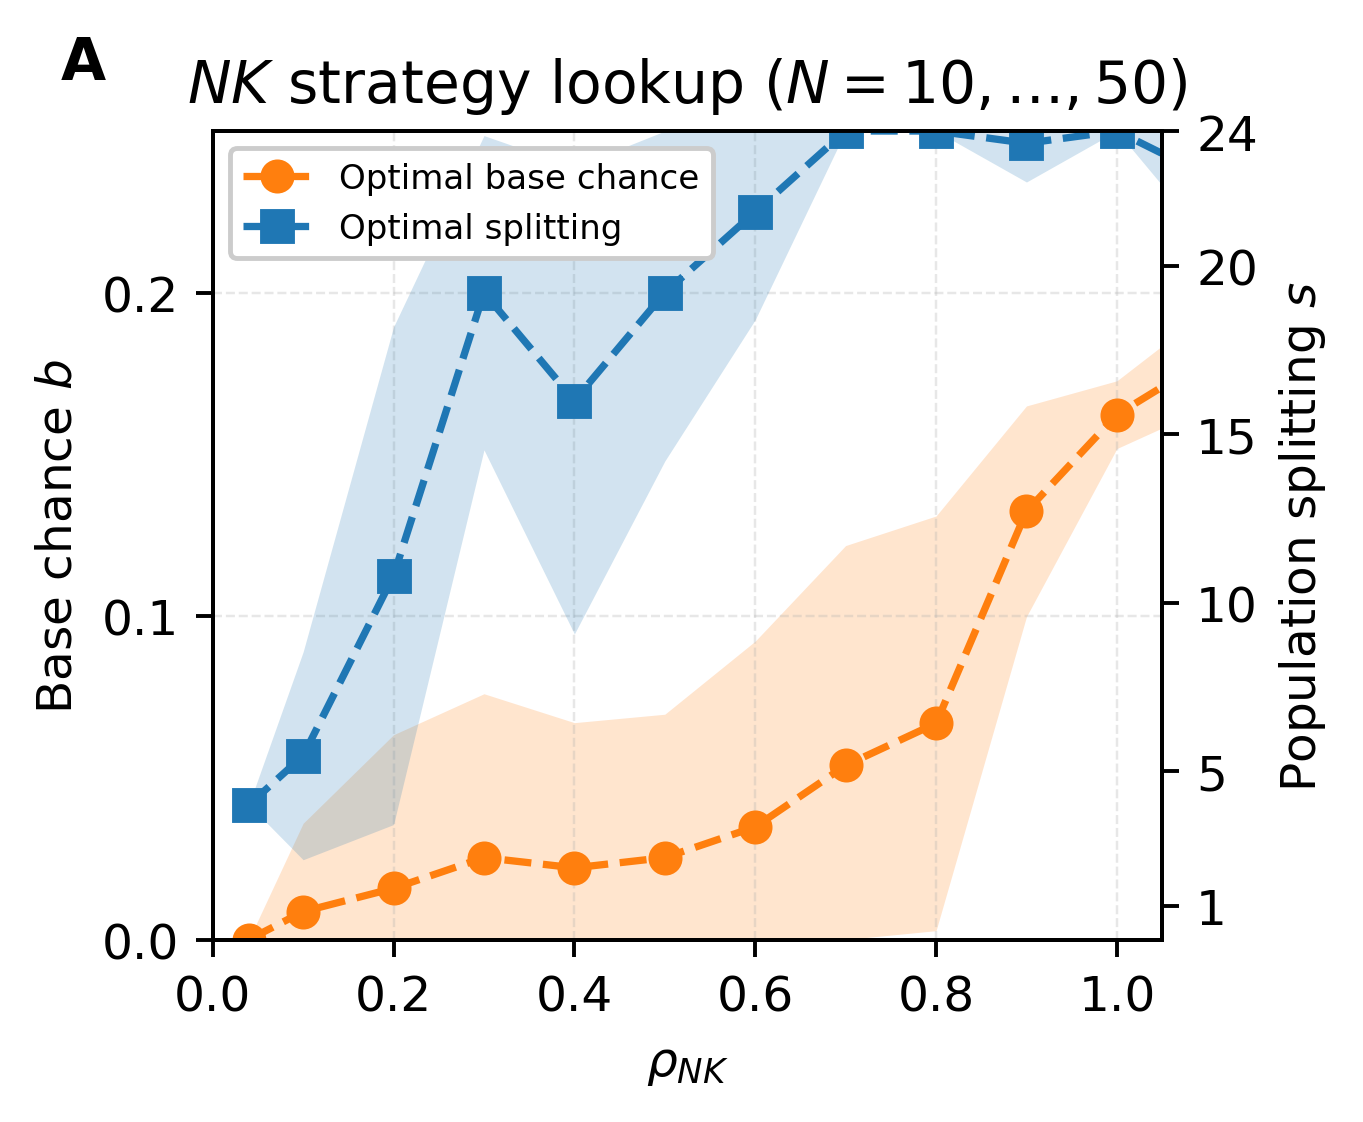

In [ ]:
def plot_strategy_lookup(ax: plt.Axes, lookup: dict, *, title: str = "Graphical look-up table") -> plt.Axes:
    """Plot the Figure 5A lookup: per-rho optimal base chance and splitting.

    Parameters:
    - ax: plt.Axes
        Primary axis for optimal base chance.
    - lookup: dict
        Processed NK strategy lookup values.
    - title: str
        Panel title.

    Returns:
    - plt.Axes
        Twin axis used for population splitting.
    """
    color_base = "tab:orange"
    color_split = "tab:blue"
    rho = lookup["grouped_rho"]
    rho[0] = 0.04
    ax2 = ax.twinx()
    base_mean = np.asarray(lookup["base_chance_mean"], dtype=float)
    base_std = np.asarray(lookup["base_chance_std"], dtype=float)
    split_mean = np.asarray(lookup["split_mean"], dtype=float)
    split_std = np.asarray(lookup["split_std"], dtype=float)
    ax.plot(rho, base_mean, "o--", color=color_base, label="Optimal base chance")
    ax.fill_between(rho, np.clip(base_mean - base_std, 0.0, 0.2), np.clip(base_mean + base_std, 0.0, 0.2), color=color_base, alpha=0.2, linewidth=0)
    ax2.plot(rho, split_mean, "s--", color=color_split, label="Optimal splitting")
    ax2.fill_between(rho, np.clip(split_mean - split_std, 1.0, 24.0), np.clip(split_mean + split_std, 1.0, 24.0), color=color_split, alpha=0.2, linewidth=0)
    ax.set_ylim(0.0, 0.2)
    ax2.set_ylim(0, 24.0)
    ax.set_yticks([0, 0.1, 0.2])
    ax2.set_yticks([1, 5, 10, 15, 20, 24])
    ax.set_xlabel(r"$\rho_{NK}$")
    ax.set_ylabel(r"Base chance $b$", color="black")
    ax2.set_ylabel("Population splitting $s$", color="black")
    ax.tick_params(axis="y", labelcolor="black")
    ax2.tick_params(axis="y", labelcolor="black")
    ax.set_xlim(0.0, 1.05)
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_title(title)
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    legend = ax2.legend(handles1 + handles2, labels1 + labels2, fontsize=7, frameon=True, framealpha=1.0, loc="upper left")
    legend.set_zorder(10)
    return ax2

fig, ax = plt.subplots(figsize=(3.5, 3.0), dpi=PANEL_DPI)
plot_strategy_lookup(ax, strategy_lookup, title="$NK$ strategy lookup ($N=10,\ldots,50$)")
add_panel_letter(ax, "A")
save_panel_figure(fig, "figure_5A")
plt.show()


## Processing — Panels B and C NK Examples

Select one smooth and one rugged NK setting from the lookup. For each example, reduce the raw strategy sweep to its mean performance surface, identify the true grid optimum, obtain the SLIDE choice from the ruggedness lookup, and summarise generation-wise best-variant trajectories for the baseline, selected, optimal, and high-exploration strategies.

In [32]:
def build_nk_examples_payload():
    params = nk_lookup_payload["params"]
    grid_size = int(params["strategy_grid_size"])
    base_chances = np.asarray(params["base_chances"], dtype=float)
    thresholds = np.asarray(params["thresholds"], dtype=float)
    splits = np.asarray(params["splits"], dtype=int)
    nk_pairs = [tuple(map(int, pair)) for pair in params["nk_pairs"]]
    lookup_raw = np.asarray(nk_lookup_payload["data"], dtype=float)
    pair_to_index = {pair: index for index, pair in enumerate(nk_pairs)}

    examples = {}
    for panel, config in NK_EXAMPLE_PAIRS.items():
        pair = (int(config["N"]), int(config["K"]))
        if pair not in pair_to_index:
            raise ValueError(f"NK example pair {pair} is not present in the lookup grid.")

        raw_index = pair_to_index[pair]
        strategy_space = mean_strategy_space(lookup_raw[raw_index], grid_size, layout="split_base_reps")
        optimum_row, optimum_column = strategy_index(strategy_space)
        optimum = strategy_choice_from_index(optimum_row, optimum_column, base_chances, splits, name="Optimum", color=OPTIMUM_STRATEGY["color"])
        slide = {**optimum, "name": "SLIDE", "color": SLIDE_STRATEGY["color"]}
        baseline_row, baseline_column = strategy_index_from_values(BASELINE_STRATEGY["split"], BASELINE_STRATEGY["base_chance"], base_chances, splits)
        baseline = strategy_choice_from_index(baseline_row, baseline_column, base_chances, splits, name="Baseline", color=BASELINE_STRATEGY["color"])
        he_row, he_column = strategy_index_from_values(int(splits[0]), float(base_chances[-1]), base_chances, splits)
        high_exploration = strategy_choice_from_index(he_row, he_column, base_chances, splits, name="HE", color=HIGH_EXPLORATION_STRATEGY["color"])

        N, K = pair
        # Pass the landscape to the fused kernel via traced arrays (one compile, reused across strategies).
        interaction_matrix, site_rng, offset_rng = nk_landscape_arrays(jr.PRNGKey(TRACE_SEED + raw_index), N, K)
        strategy_choices = {"Baseline": baseline, "SLIDE": slide, "Optimum": optimum, "HE": high_exploration}

        # Per-replicate random starts (shared across strategies) plus a distinct key per strategy.
        rep_keys = jr.split(jr.PRNGKey(TRACE_SEED + 1000 + raw_index), NK_TRACE_REPS)
        rep_splits = jax.vmap(lambda rep_key: jr.split(rep_key, 1 + len(strategy_choices)))(rep_keys)
        start_keys = rep_splits[:, 0]
        strategy_keys = rep_splits[:, 1:]
        start_coords = jax.vmap(lambda key: jr.randint(key, (N,), 0, int(params["A"])))(start_keys).astype(jnp.int32)

        curves_by_strategy = {}
        for position, (strategy_name, choice) in enumerate(strategy_choices.items()):
            threshold = strategy_threshold(choice["base_chance"], thresholds, base_chances)
            curves = best_variant_traces_nk(
                strategy_keys[:, position],
                start_coords,
                jnp.asarray(float(choice["base_chance"])),
                jnp.asarray(float(threshold)),
                interaction_matrix,
                site_rng,
                offset_rng,
                n_sites=N,
                num_alleles=int(params["A"]),
                split=int(choice["split"]),
                popsize=int(params["popsize"]),
                mutation_rate=float(params["mutation_rate"]) / N,
                num_steps=int(params["M"]),
            )
            curves_by_strategy[strategy_name] = np.asarray(curves)

        examples[panel] = {
            "label": config["label"],
            "N": N,
            "K": K,
            "rho_NK": float((K + 1) / N),
            "strategy_space": strategy_space,
            "base_chances": base_chances,
            "thresholds": thresholds,
            "splits": splits,
            "choices": strategy_choices,
            "traces": summarize_strategy_traces(curves_by_strategy),
            "generations": np.arange(int(params["M"])),
        }

    return {
        "data": examples,
        "params": {"trace_reps": NK_TRACE_REPS, "trace_seed": TRACE_SEED, **params},
        "metadata": {"paper_reference": "Figure 5B-C", "description": "NK directed-evolution trajectory examples (Baseline, SLIDE, Optimum, HE) with separate strategy-space inserts."},
    }


nk_examples_payload = load_or_build_processed("nk_examples", build_nk_examples_payload)
nk_examples = nk_examples_payload["data"]
for panel, payload in nk_examples.items():
    print(panel, payload["label"], "N", payload["N"], "K", payload["K"], "SLIDE", payload["choices"]["SLIDE"])

Loaded figure5_nk_examples_processed.pkl
B Smooth NK N 45 K 1 SLIDE {'name': 'SLIDE', 'split_index': 5, 'base_index': 0, 'split': 4, 'base_chance': 0.0, 'color': 'tab:blue'}
C Rugged NK N 45 K 25 SLIDE {'name': 'SLIDE', 'split_index': 2, 'base_index': 0, 'split': 16, 'base_chance': 0.0, 'color': 'tab:blue'}


## Individual Panels B and C

Plot the directed-evolution fitness trajectories for the smooth and rugged NK examples and their compact strategy-performance surfaces. All curves are calculated from the processed simulation replicates rather than from new simulations in the plotting cell.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


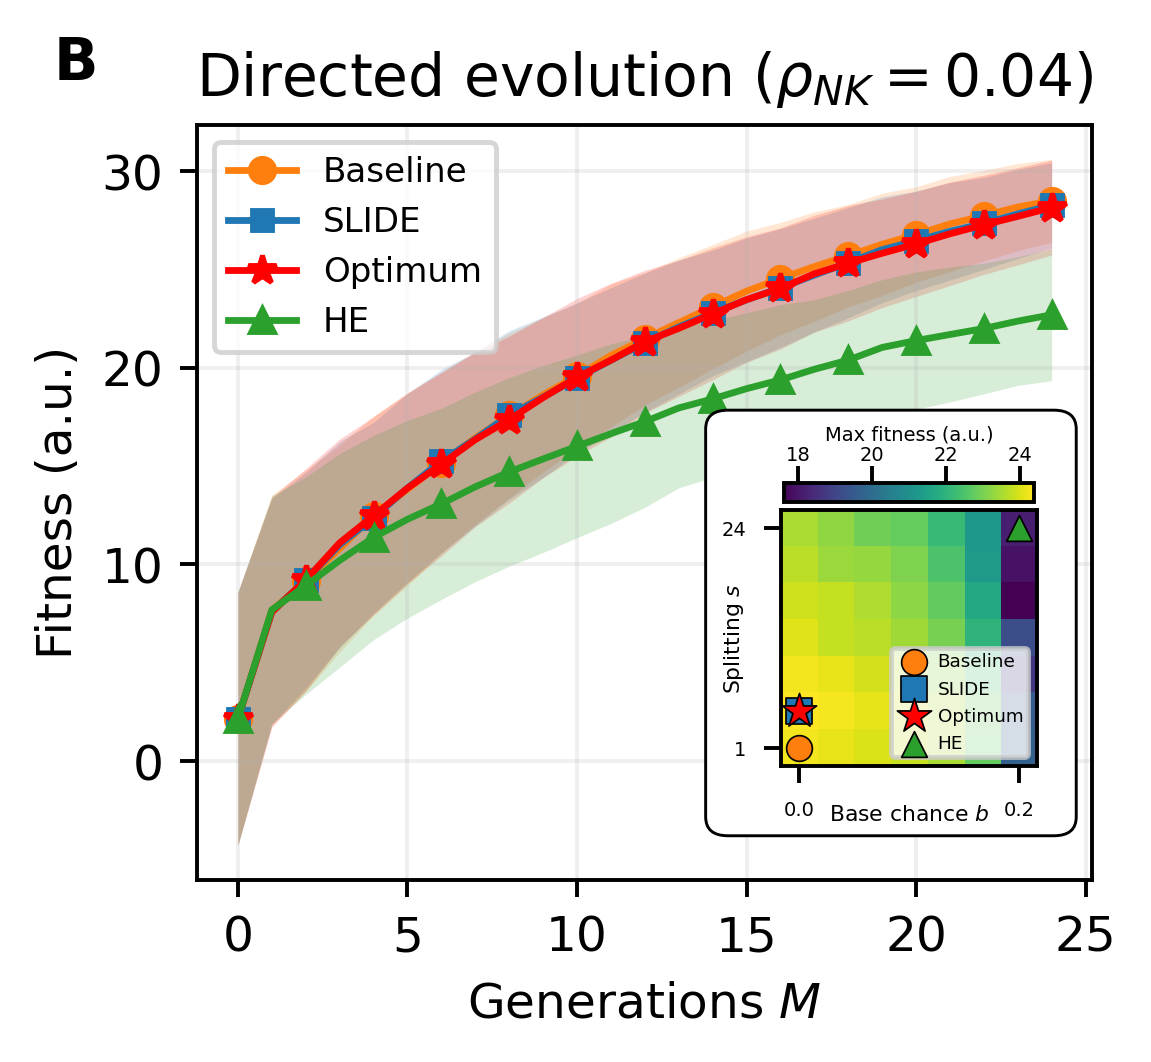

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


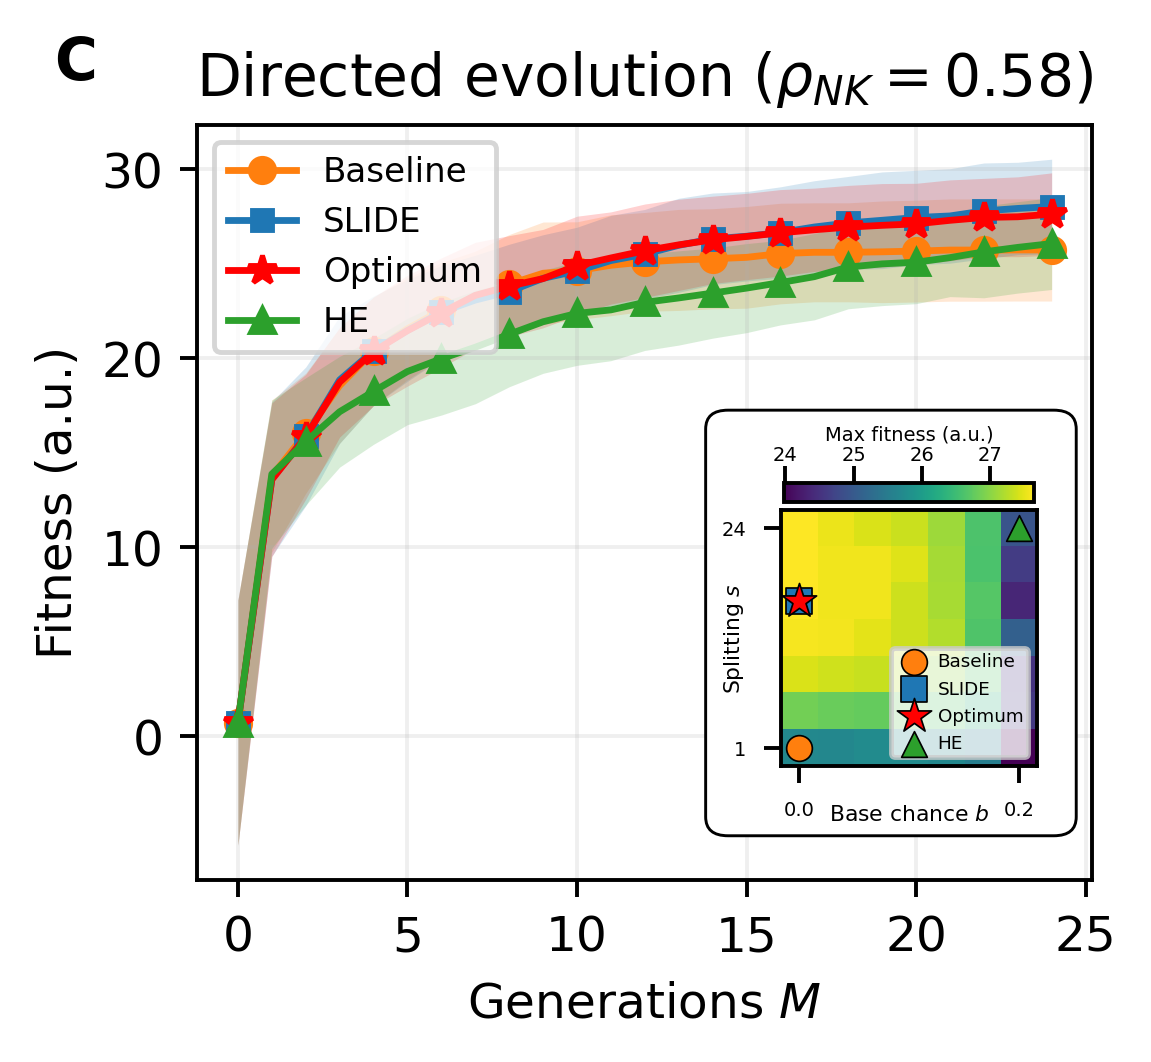

In [33]:
TRACE_STRATEGY_ORDER = ["Baseline", "SLIDE", "Optimum", "HE"]
TRACE_STRATEGY_MSTYLE = ["o-", "s-", "*-", "^-"]
TRACE_STRATEGY_MARKERSIZE = [5, 4, 6, 5]


def plot_trace_summary(ax: plt.Axes, payload: dict, *, title: str, ylabel: str = "Fitness (a.u.)") -> None:
    """Plot Baseline, SLIDE, Optimum, and HE trajectory summaries with standard-deviation bands."""
    generations = payload["generations"]
    for name, mstyle, msize in zip(TRACE_STRATEGY_ORDER, TRACE_STRATEGY_MSTYLE, TRACE_STRATEGY_MARKERSIZE, strict=True):
        trace = payload["traces"][name]
        color = payload["choices"][name]["color"]
        ax.plot(generations, trace["mean"], mstyle, markersize=msize, markevery=2, color=color, linewidth=1.4, label=name)
        ax.fill_between(generations, trace["mean"] - trace["std"], trace["mean"] + trace["std"], color=color, alpha=0.18, linewidth=0)
    ax.set_title(title)
    ax.set_xlabel(r"Generations $M$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=True, loc="upper left")
    ax.grid(True, alpha=0.2)


def plot_strategy_space(
    ax: plt.Axes,
    payload: dict,
    *,
    title: str | None = "Strategy performance",
    vmin: float | None = None,
    vmax: float | None = None,
    value_scale: float = 1.0,
    aspect: str = "equal",
    xlabel_pad: float = 4.0,
    ylabel_pad: float = -10,
    base_tick_decimals: int = 2,
    base_tick_labels: tuple[str, str] | None = None,
    marker_styles: dict[str, str] | None = None,
    slide_rho_nk: float | None = None,
    label_fontsize: float | None = None,
    tick_fontsize: float | None = None,
    legend_fontsize: float = 5.5,
) -> AxesImage:
    """Plot a strategy-performance heat map with baseline, SLIDE, optimum, and HE markers.

    `value_scale` rescales the colour values (e.g. 100 to express max final fitness as a
    percentage of wild-type), keeping the heat-map colours identical and only changing the
    colourbar units so they match the directed-evolution trajectory axis.
    """
    space = np.asarray(payload["strategy_space"], dtype=float) * value_scale
    image = ax.imshow(space, aspect=aspect, origin="upper", cmap="viridis", vmin=vmin, vmax=vmax)
    if aspect == "equal":
        ax.set_box_aspect(1)
    base_chances = np.asarray(payload["base_chances"], dtype=float)
    splits = np.asarray(payload["splits"], dtype=int)
    for name in ["Baseline", "SLIDE", "Optimum", "HE"]:
        choice = payload["choices"][name]
        row, column = strategy_index_from_values(choice["split"], choice["base_chance"], base_chances, splits)
        marker = marker_styles[name] if marker_styles is not None else ("o" if name != "Optimum" else "*")
        size = 28 if name != "Optimum" else 55
        legend_label = rf"SLIDE ($\rho_{{NK}}={slide_rho_nk:.2f}$)" if name == "SLIDE" and slide_rho_nk is not None else name
        ax.scatter(column, row, s=size, color=choice["color"], marker=marker, edgecolors="black", linewidth=0.35, label=legend_label)
    ax.set_xticks([0, len(base_chances) - 1])
    if base_tick_labels is None:
        base_tick_labels = (f"{base_chances[0]:.{base_tick_decimals}f}", f"{base_chances[-1]:.{base_tick_decimals}f}")
    ax.set_xticklabels(base_tick_labels)
    ax.set_yticks([0, len(splits) - 1])
    ax.set_yticklabels([str(splits[0]), str(splits[-1])])
    ax.set_xlabel(r"Base chance $b$", labelpad=xlabel_pad, fontsize=label_fontsize)
    ax.set_ylabel(r"Splitting $s$", labelpad=ylabel_pad, fontsize=label_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
    if title:
        ax.set_title(title)
    ax.legend(fontsize=legend_fontsize, frameon=True, loc="lower right", ncol=1, columnspacing=0.65, handletextpad=0.25, borderpad=0.25)
    return image


def add_strategy_inset(
    ax: plt.Axes,
    payload: dict,
    *,
    border_bounds: tuple[float, float, float, float] = (0.58, 0.07, 0.39, 0.54),
    xlabel_pad: float = -3,
) -> None:
    """Add a compact strategy-space heat map to a trajectory axis.

    Parameters:
    - ax: plt.Axes
        Parent directed-evolution axis.
    - payload: dict
        Processed NK example containing the strategy space and choices.
    - border_bounds: tuple[float, float, float, float]
        Bounding box around the inset in parent-axis coordinates.
    - xlabel_pad: float
        Padding between the inset x-axis ticks and label.

    Returns:
    - None
        The inset artists are added directly to ``ax``.
    """
    border = FancyBboxPatch(
        border_bounds[:2], border_bounds[2], border_bounds[3],
        boxstyle="round,pad=0.012,rounding_size=0.025",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
    )
    ax.add_patch(border)
    inset_ax = ax.inset_axes([0.62, 0.15, 0.35, 0.34], zorder=6)
    image = plot_strategy_space(
        inset_ax,
        payload,
        title=None,
        xlabel_pad=xlabel_pad,
        ylabel_pad=-5,
        base_tick_decimals=1,
        marker_styles=dict(zip(TRACE_STRATEGY_ORDER, [style[0] for style in TRACE_STRATEGY_MSTYLE], strict=True)),
        label_fontsize=4.5,
        tick_fontsize=4,
        legend_fontsize=3.8,
    )
    colorbar_ax = ax.inset_axes([0.655, 0.5, 0.28, 0.025], zorder=6)
    colorbar = ax.figure.colorbar(image, cax=colorbar_ax, orientation="horizontal")
    colorbar.set_label("Max fitness (a.u.)", fontsize=4, labelpad=1)
    colorbar.ax.xaxis.set_label_position("top")
    colorbar.ax.xaxis.set_ticks_position("top")
    colorbar.ax.tick_params(labelsize=4, pad=0.5)

for panel in ["B", "C"]:
    payload = nk_examples[panel]
    fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=PANEL_DPI)
    plot_trace_summary(ax, payload, title=rf"Directed evolution ($\rho_{{NK}}={payload['rho_NK']:.2f}$)")
    add_strategy_inset(ax, payload)
    add_panel_letter(ax, panel)
    save_panel_figure(fig, f"figure_5{panel}")
    plt.show()

## Processing — Panels D–G Empirical Landscapes

For each empirical landscape, form the global squared-fitness decay curve, fit its decay rate, and use that estimate to select base chance and splitting from the $N=4$, $A=20$ NK lookup. Average the empirical strategy scores into a performance surface and compare baseline and SLIDE-selected directed-evolution trajectories across the sampled starting genotypes and replicates.

In [34]:
def fit_decay_curve(raw_g_mu: np.ndarray, *, mutation_rate: float, num_steps: int) -> tuple[float, np.ndarray, np.ndarray]:
    """Fit G_mu and return rho_2 plus the asymptote-subtracted decay curve and fitted line.

    Matches the published figure: the fitted plateau (landscape-mean level) is subtracted and
    the result renormalised, so both the data and the fit decay from 1 down to 0.
    """
    decay_rate = get_single_decay_rate(raw_g_mu, mut=mutation_rate, num_steps=num_steps)
    asymptote = decay_rate[1]
    x_vals = np.linspace(0, num_steps - 1, num_steps)
    curve = np.asarray(raw_g_mu, dtype=float) - asymptote
    curve = curve / curve[0]
    fit = np.asarray(model_function(x_vals, *decay_rate, mut=mutation_rate), dtype=float) - asymptote
    fit = fit / fit[0]
    return float(decay_rate[0] / 2), curve, fit


def build_nk_lookup(decay_key: str, strategy_key: str) -> dict:
    """Build a decay-rate -> optimal-strategy lookup from one NK decay + strategy product pair.

    Used for both N=4 (GB1/TrpB/TEV) and N=3 (ParD3) so each empirical landscape is matched to a
    lookup of the correct dimensionality and grid size.
    """
    decay = np.asarray(load_raw_payload(decay_key)["data"], dtype=float)
    strategy_payload = load_raw_payload(strategy_key)
    strategy = np.asarray(strategy_payload["data"], dtype=float)
    decay_params = load_raw_payload(decay_key)["params"]
    strategy_params = strategy_payload["params"]
    grid_size = int(strategy_params["strategy_grid_size"])
    base_chances = np.asarray(strategy_params["base_chances"], dtype=float)
    splits = np.asarray(strategy_params["splits"], dtype=int)
    k_values = np.asarray(decay_params["K_values"], dtype=int)

    rho_values, optimal_splits, optimal_base_chances = [], [], []
    for k_index, _k in enumerate(k_values):
        g_mu = normalized_gmu(decay[k_index])
        rho, _curve, _fit = fit_decay_curve(g_mu, mutation_rate=float(decay_params["mutation_rate"]), num_steps=int(decay_params["M"]))
        space = mean_strategy_space(strategy[:, k_index], grid_size, layout="last_base_split")
        row, column = strategy_index(space)
        rho_values.append(rho)
        optimal_splits.append(int(splits[row]))
        optimal_base_chances.append(float(base_chances[column]))

    order = np.argsort(rho_values)
    n_sites = int(decay_params["N"])
    return {
        "N": n_sites,
        "K_values": k_values[order],
        "rho_NK_values": (k_values[order] + 1) / n_sites,
        "rho_values": np.asarray(rho_values)[order],
        "optimal_splits": np.asarray(optimal_splits)[order],
        "optimal_base_chances": np.asarray(optimal_base_chances)[order],
        "base_chances": base_chances,
        "splits": splits,
    }


# One lookup per dimensionality: N=4 (GB1/TrpB/TEV, 7x7) and N=3 (ParD3, 5x5).
empirical_nk_lookups = {
    4: build_nk_lookup("nk_decay_N4_A20", "nk_strategy_N4_A20"),
    3: build_nk_lookup("nk_decay_N3_A20", "nk_strategy_N3_A20"),
}


def build_empirical_payload():
    processed = {}
    for name in EMPIRICAL_NAMES:
        decay_payload = empirical_decay_payloads[name]
        traj_payload = empirical_traj_payloads[name]
        landscape = empirical_landscapes[name]
        params = traj_payload["params"]
        base_chances = np.asarray(params["base_chances"], dtype=float)
        thresholds = np.asarray(params["thresholds"], dtype=float)
        splits = np.asarray(params["splits"], dtype=int)

        # The ONE dataset: best-variant trajectory per (start, split, base) cell.
        traj = np.asarray(traj_payload["data"], dtype=float)        # (starts, splits, base, steps)
        heatmap_gen = int(params.get("heatmap_gen", traj.shape[-1]))
        heatmap_index = min(heatmap_gen, traj.shape[-1]) - 1        # heat map = calibration-point slice (e.g. gen 25)
        strategy_space = traj[..., heatmap_index].mean(axis=0)      # while the lines below use the full trajectory
        trace_mean = traj.mean(axis=0)                             # (splits, base, steps)
        trace_std = traj.std(axis=0)
        num_steps = traj.shape[-1]

        # Decay panel + rho_2 (independent decay product).
        raw_g_mu = normalized_gmu(decay_payload["data"])
        rho, g_mu, fit = fit_decay_curve(raw_g_mu, mutation_rate=float(decay_payload["params"]["mutation_rate"]), num_steps=int(decay_payload["params"]["M"]))

        slide_pick = nearest_lookup_strategy(rho, empirical_nk_lookups[landscape.ndim])

        def make_choice(label: str, split: int, base_chance: float, color: str) -> dict:
            row, column = strategy_index_from_values(split, base_chance, base_chances, splits)
            choice = strategy_choice_from_index(row, column, base_chances, splits, name=label, color=color)
            choice["trace_mean"] = trace_mean[row, column]
            choice["trace_std"] = trace_std[row, column]
            return choice

        optimum_row, optimum_column = strategy_index(strategy_space)
        choices = {
            "Baseline": make_choice("Baseline", BASELINE_STRATEGY["split"], BASELINE_STRATEGY["base_chance"], BASELINE_STRATEGY["color"]),
            "SLIDE": make_choice("SLIDE", slide_pick["split"], slide_pick["base_chance"], SLIDE_STRATEGY["color"]),
            "Optimum": make_choice("Optimum", int(splits[optimum_row]), float(base_chances[optimum_column]), OPTIMUM_STRATEGY["color"]),
            "HE": make_choice("HE", int(splits[0]), float(base_chances[-1]), HIGH_EXPLORATION_STRATEGY["color"]),
        }
        choices["SLIDE"].update({key: value for key, value in slide_pick.items() if key.startswith("lookup_")})
        traces = {name_: {"mean": choice["trace_mean"], "std": choice["trace_std"]} for name_, choice in choices.items()}

        processed[name] = {
            "g_mu": g_mu,
            "fit": fit,
            "decay_generations": np.arange(g_mu.shape[0]),
            "rho2_fit": rho,
            "rho2_dirichlet": float(get_dirichlet_metric(landscape, on_gpu=False)),
            "rho_nk_lookup": slide_pick["lookup_rho_NK"],
            "strategy_space": strategy_space,
            "base_chances": base_chances,
            "thresholds": thresholds,
            "splits": splits,
            "choices": choices,
            "traces": traces,
            "trace_generations": np.arange(num_steps),
            "popsize": int(params["popsize"]),
            "decay_params": decay_payload["params"],
            "strategy_params": params,
        }

    return {
        "data": processed,
        "params": {"trace_steps": int(empirical_traj_payloads[EMPIRICAL_NAMES[0]]["params"]["M"]), "trace_seed": TRACE_SEED},
        "metadata": {"paper_reference": "Figure 5D-G", "description": "Empirical panels: heat map (final slice) and DE lines derived from one best-variant trajectory sweep; ParD3 handled as N=3."},
    }


empirical_payload = load_or_build_processed("empirical", build_empirical_payload)
empirical_data = empirical_payload["data"]
for name, payload in empirical_data.items():
    if "rho2_dirichlet" not in payload:
        payload["rho2_dirichlet"] = float(get_dirichlet_metric(empirical_landscapes[name], on_gpu=False))
    if "rho_nk_lookup" not in payload:
        landscape = empirical_landscapes[name]
        slide_pick = nearest_lookup_strategy(payload["rho2_fit"], empirical_nk_lookups[landscape.ndim])
        payload["rho_nk_lookup"] = slide_pick["lookup_rho_NK"]
        payload["choices"]["SLIDE"].update({key: value for key, value in slide_pick.items() if key.startswith("lookup_")})

for name, payload in empirical_data.items():
    print(name, "rho2", f"{payload['rho2_dirichlet']:.3f}", "rho2_fit", f"{payload['rho2_fit']:.3f}", "SLIDE", payload["choices"]["SLIDE"]["split"], payload["choices"]["SLIDE"]["base_chance"], "popsize", payload["popsize"])

Loaded figure5_empirical_processed.pkl
GB1 rho2 0.598 rho2_fit 0.613 SLIDE 16 0.0 popsize 1200
TrpB rho2 0.602 rho2_fit 0.628 SLIDE 16 0.0 popsize 1200
TEV rho2 0.944 rho2_fit 0.995 SLIDE 24 0.15833333134651184 popsize 1200
ParD3 rho2 0.423 rho2_fit 0.431 SLIDE 20 0.0 popsize 60


## Individual Panels D–G

Plot one row for each empirical landscape: its normalised squared-fitness decay and fitted curve, its mean strategy-performance surface with the selected strategy, and its baseline-versus-SLIDE directed-evolution trajectories.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


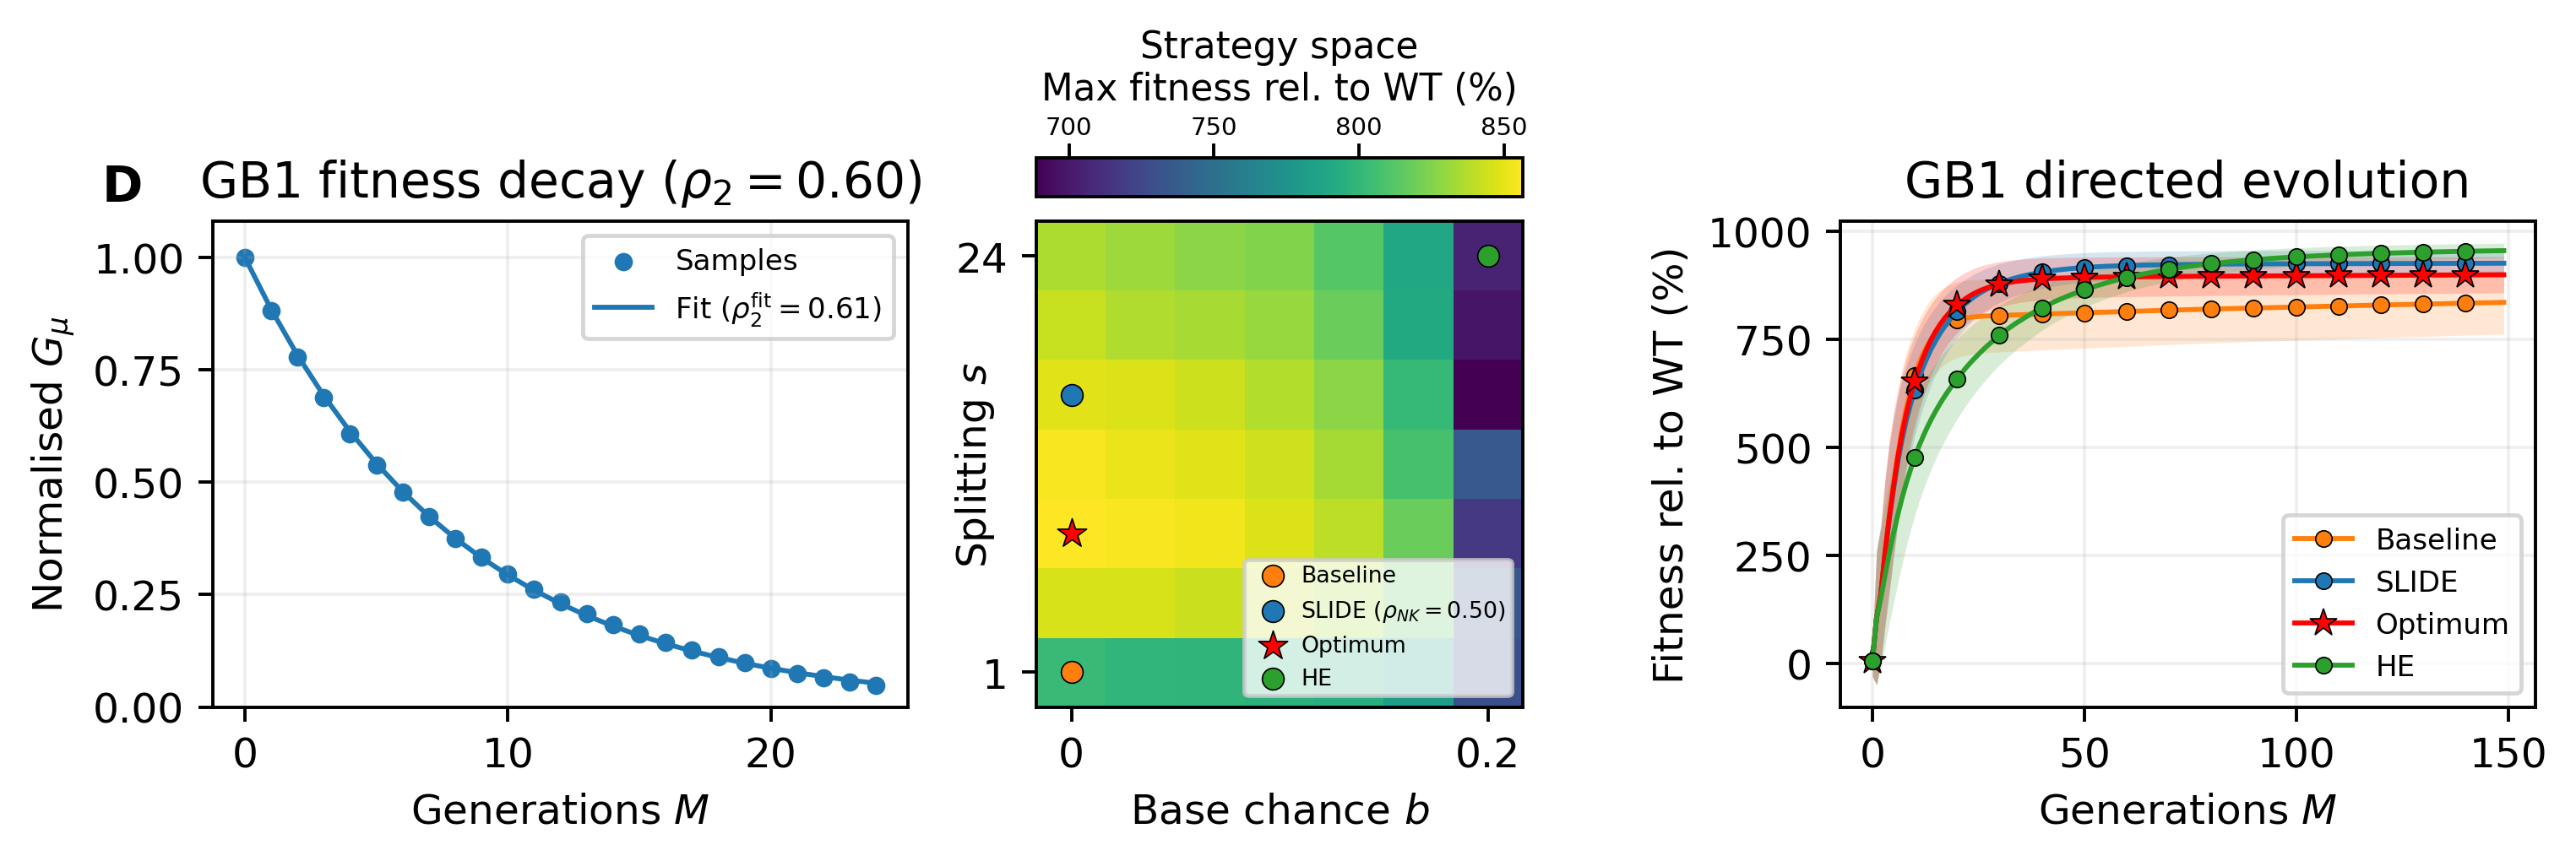

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


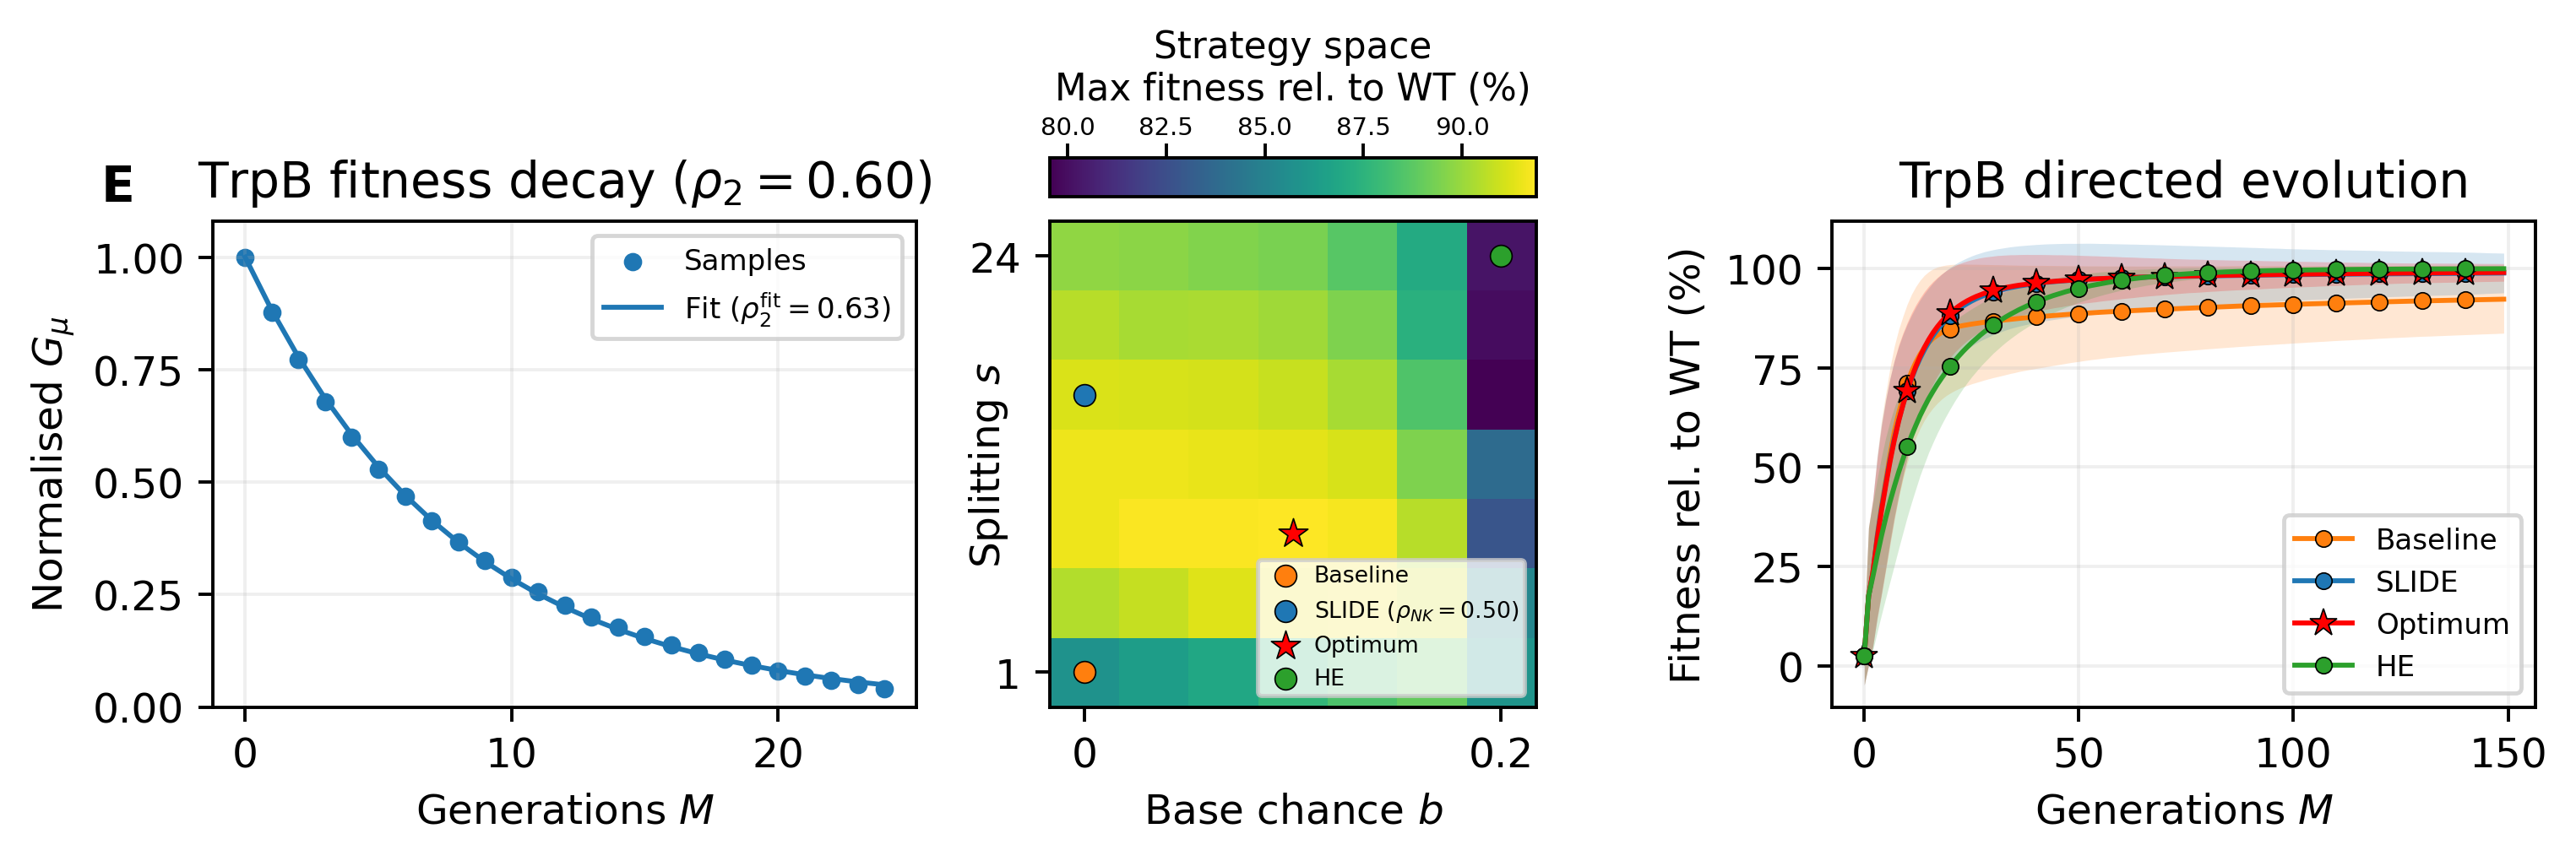

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


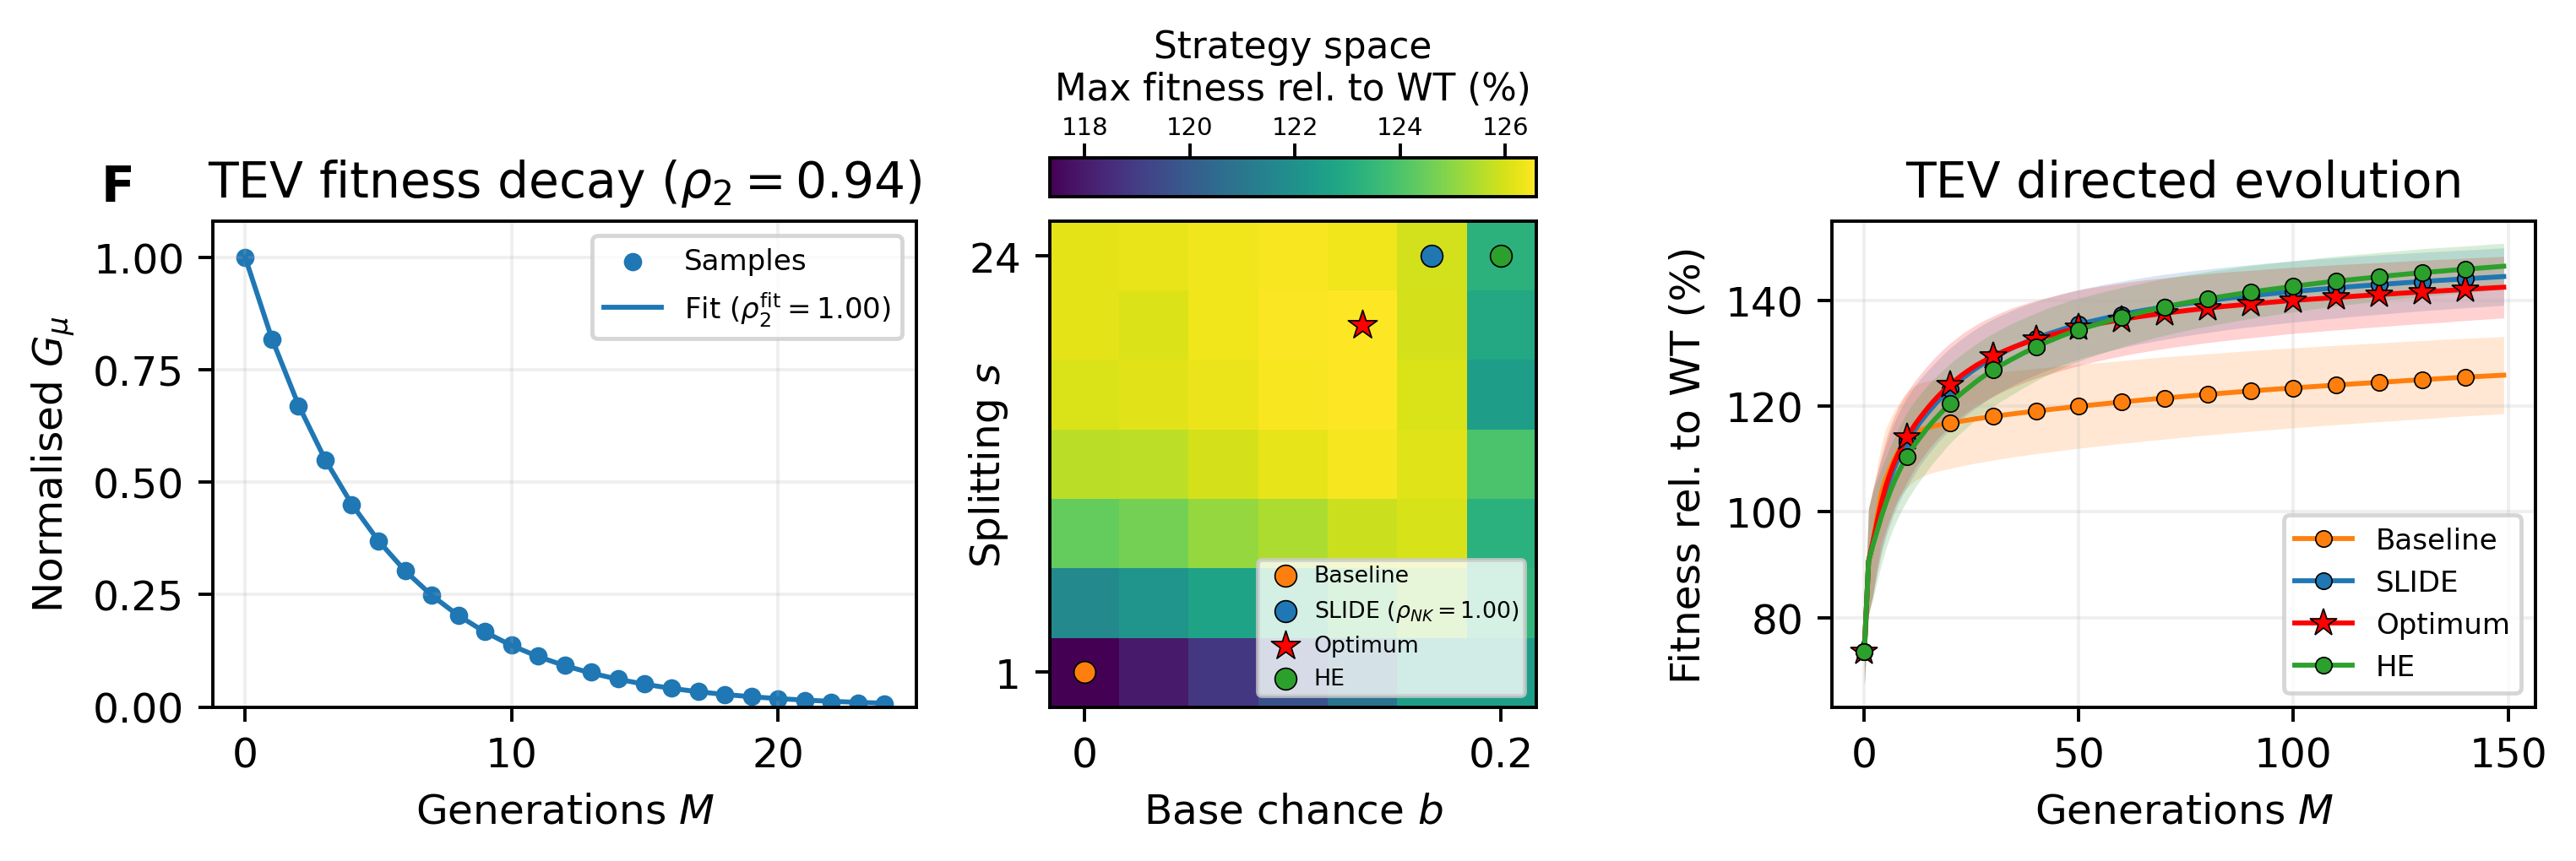

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


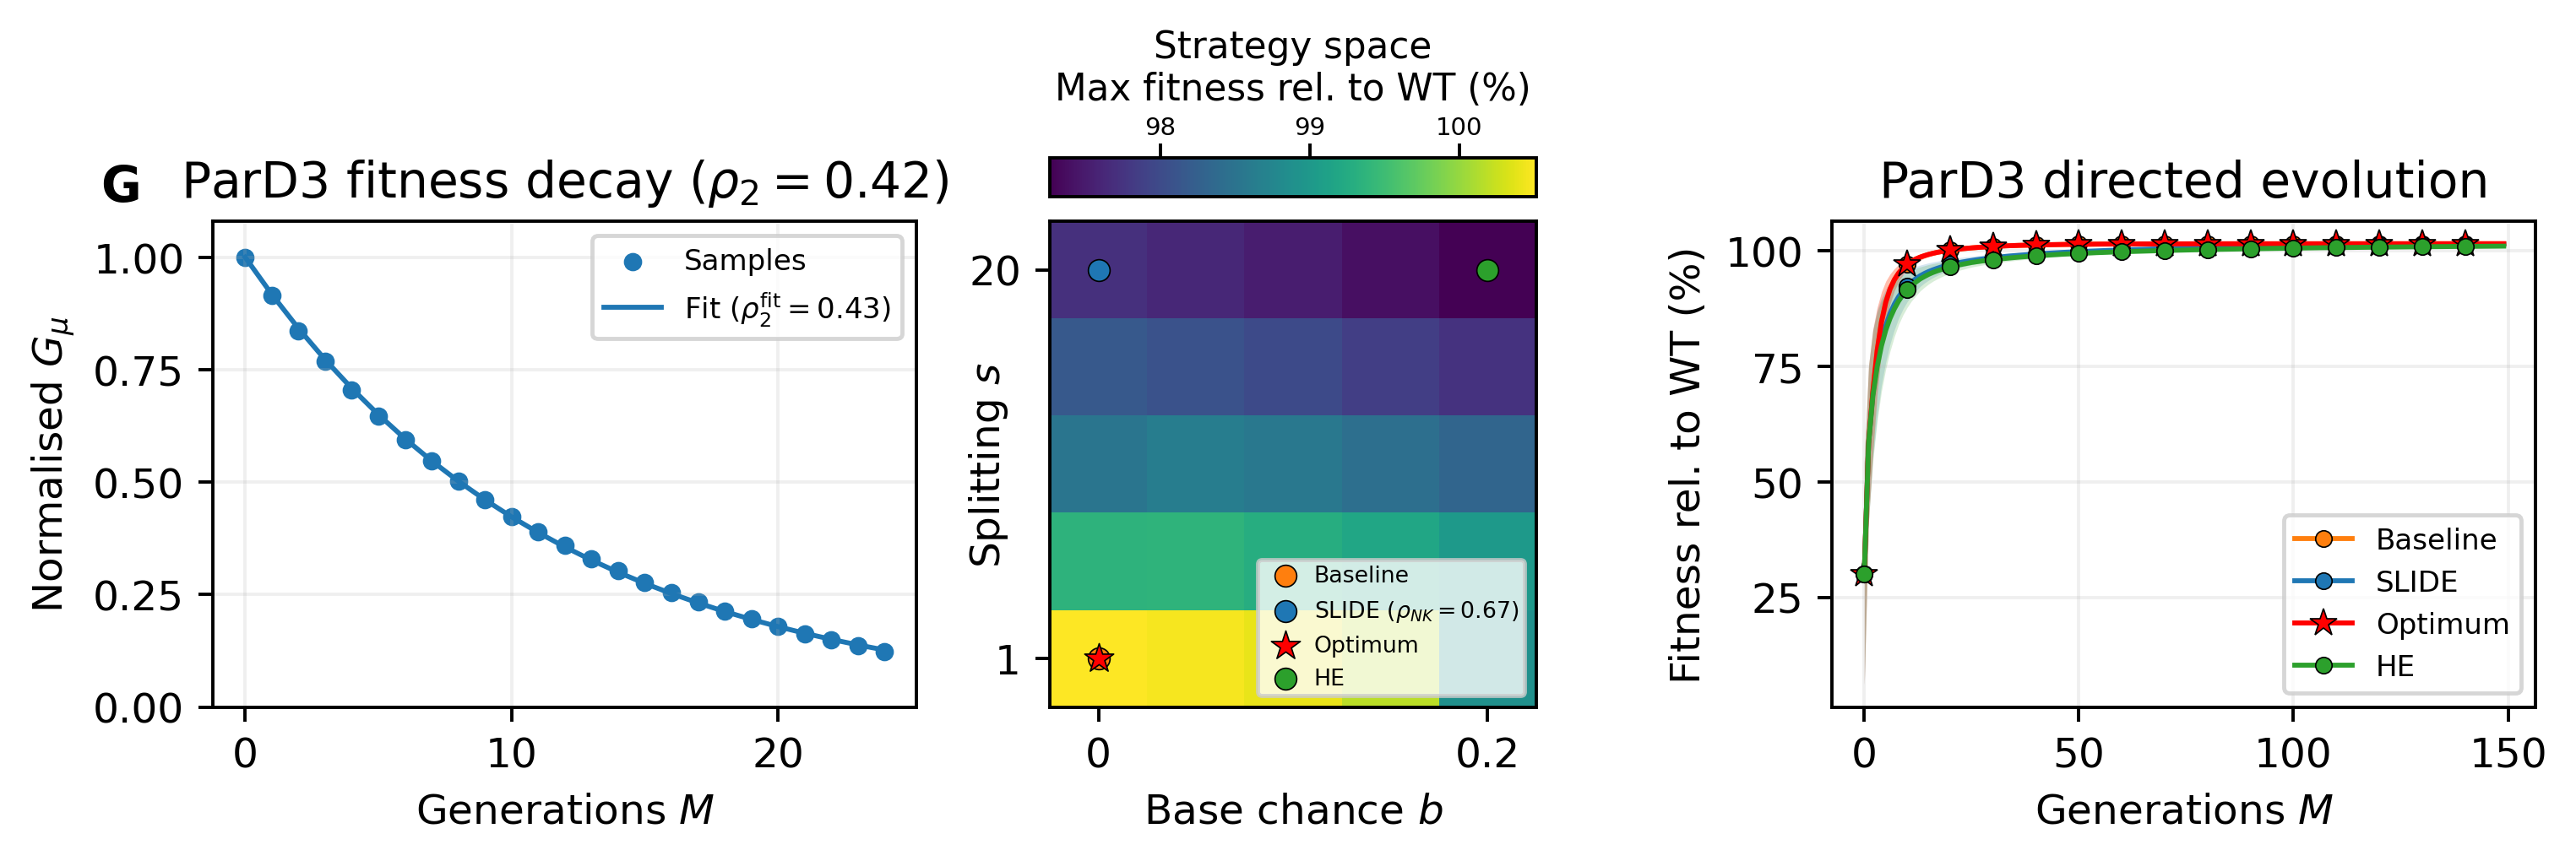

In [35]:
def plot_decay_panel(ax: plt.Axes, payload: dict, *, name: str) -> None:
    """Plot the empirical G_mu decay curve (asymptote-subtracted) and fitted line."""
    ax.scatter(payload["decay_generations"], payload["g_mu"], s=12, color="tab:blue", label=r"Samples")
    ax.plot(payload["decay_generations"], payload["fit"], color="tab:blue", linewidth=1.2, label=rf"Fit ($\rho_2^{{\mathrm{{fit}}}}={payload['rho2_fit']:.2f}$)")
    ax.set_ylim(0, 1.08)
    ax.set_title(rf"{name} fitness decay ($\rho_2={payload['rho2_dirichlet']:.2f}$)")
    ax.set_xlabel(r"Generations $M$")
    ax.set_ylabel(r"Normalised $G_\mu$")
    ax.legend(fontsize=7, frameon=True)
    ax.grid(True, alpha=0.2)


def plot_empirical_de_panel(ax: plt.Axes, payload: dict, *, name: str) -> None:
    """Plot Baseline, SLIDE, Optimum, and HE empirical directed-evolution trajectories as % of WT fitness."""
    generations = payload["trace_generations"]
    for strategy_name in TRACE_STRATEGY_ORDER:
        trace = payload["traces"][strategy_name]
        color = payload["choices"][strategy_name]["color"]
        mean = trace["mean"] * 100.0
        std = trace["std"] * 100.0
        marker = "*" if strategy_name == "Optimum" else "o"
        marker_size = 7 if strategy_name == "Optimum" else 4
        ax.plot(
            generations,
            mean,
            color=color,
            linewidth=1.2,
            marker=marker,
            markersize=marker_size,
            markevery=10,
            markeredgecolor="black",
            markeredgewidth=0.35,
            label=strategy_name,
        )
        ax.fill_between(generations, mean - std, mean + std, color=color, alpha=0.18, linewidth=0)
    ax.set_title(f"{name} directed evolution")
    ax.set_xlabel(r"Generations $M$")
    ax.set_ylabel("Fitness rel. to WT (%)")
    ax.legend(fontsize=7, frameon=True)
    ax.grid(True, alpha=0.2)


def add_strategy_colorbar(fig: plt.Figure, image: AxesImage, ax: plt.Axes, payload: dict) -> Colorbar:
    """Add the empirical strategy-performance colorbar above the heat-map axis.

    Parameters:
    - fig: plt.Figure
        Parent figure that owns the colorbar.
    - image: object
        Matplotlib image returned by ``plot_strategy_space``.
    - ax: plt.Axes
        Strategy heat-map axes.
    - payload: dict
        Empirical panel payload containing the matched NK ruggedness.

    Returns:
    - object
        Matplotlib colorbar object.
    """
    cax = ax.inset_axes([0, 1.05, 1, 0.08])
    colorbar = fig.colorbar(
        image, cax=cax, orientation="horizontal", location="top", fraction=0.10, pad=0.20, shrink=0.75
    )
    colorbar.set_label(
        "Strategy space\nMax fitness rel. to WT (%)",
        fontsize=9,
    )
    colorbar.ax.xaxis.set_label_position("top")
    colorbar.ax.xaxis.set_ticks_position("top")
    colorbar.ax.tick_params(labelsize=6, pad=1)
    return colorbar

for letter, name in zip(["D", "E", "F", "G"], EMPIRICAL_NAMES):
    payload = empirical_data[name]
    fig, axes = plt.subplots(1, 3, figsize=(8.6, 2.8), dpi=PANEL_DPI, constrained_layout=True)
    plot_decay_panel(axes[0], payload, name=name)
    image = plot_strategy_space(
        axes[1], payload, title=None, value_scale=100.0, base_tick_labels=("0", "0.2"),
        slide_rho_nk=payload["rho_nk_lookup"]
    )
    plot_empirical_de_panel(axes[2], payload, name=name)
    add_panel_letter(axes[0], letter)
    add_strategy_colorbar(fig, image, axes[1], payload)
    save_panel_figure(fig, f"figure_5{letter}")
    plt.show()

## Complete Figure

Load the processed lookup, NK examples, and empirical summaries and assemble the complete Figure 5 layout. The final figure combines the lookup, representative NK trajectories and strategy surfaces, and the empirical decay-to-strategy analyses.

In [36]:
strategy_lookup_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["strategy_lookup"])
nk_examples_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["nk_examples"])
empirical_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["empirical"])

strategy_lookup = strategy_lookup_payload["data"]
nk_examples = nk_examples_payload["data"]
empirical_data = empirical_payload["data"]
for name, payload in empirical_data.items():
    if "rho2_dirichlet" not in payload:
        payload["rho2_dirichlet"] = float(get_dirichlet_metric(empirical_landscapes[name], on_gpu=False))
    if "rho_nk_lookup" not in payload:
        landscape = empirical_landscapes[name]
        slide_pick = nearest_lookup_strategy(payload["rho2_fit"], empirical_nk_lookups[landscape.ndim])
        payload["rho_nk_lookup"] = slide_pick["lookup_rho_NK"]
        payload["choices"]["SLIDE"].update({key: value for key, value in slide_pick.items() if key.startswith("lookup_")})


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


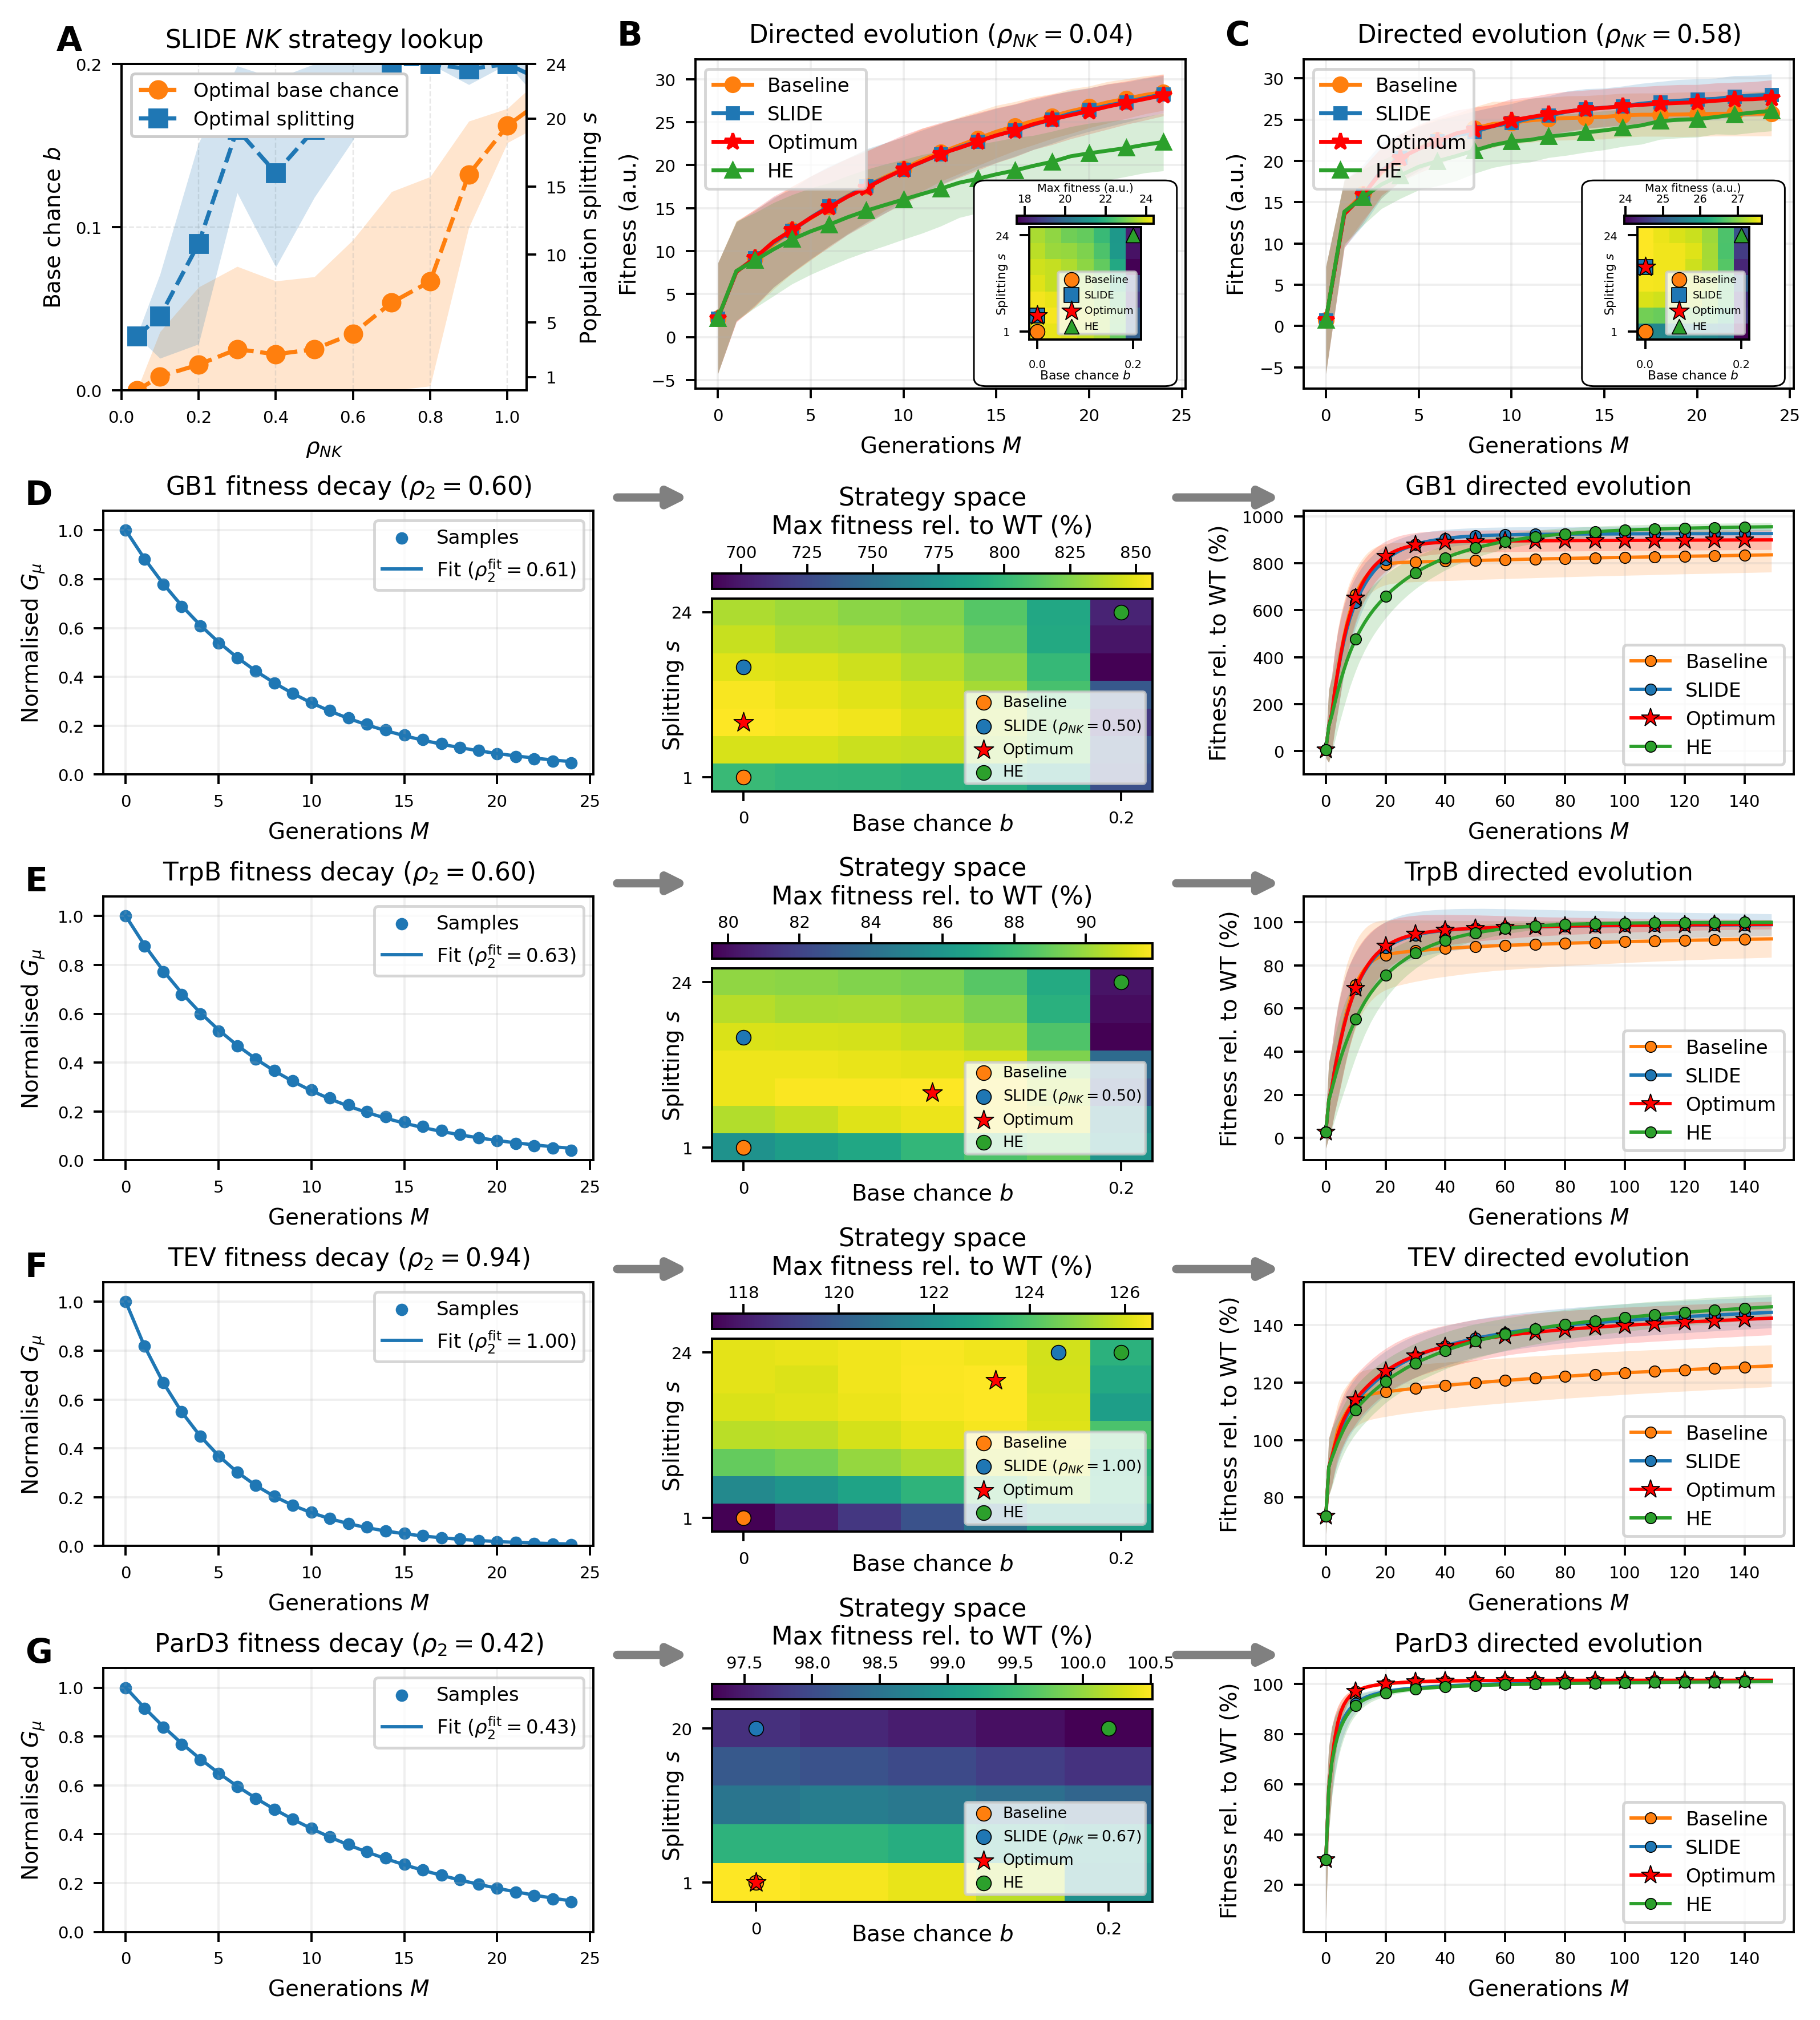

In [37]:
labelsize = 8
ticksize = 6
titlesize = 9
legendsize = 7
dpi = 350
plt.rcParams["font.family"] = "DejaVu Sans"

fig = plt.figure(figsize=(9, 10), dpi=dpi, constrained_layout=True)
gs = GridSpec(5, 3, figure=fig, height_ratios=[1, 0.8, 0.8, 0.8, 0.8], width_ratios=[1, 1, 1], wspace=0.01, hspace=0.02)

axes = {
    "A": fig.add_subplot(gs[0, 0]),
    "B": fig.add_subplot(gs[0, 1]),
    "C": fig.add_subplot(gs[0, 2]),
}
empirical_axes = {}
for row_index, letter in enumerate(["D", "E", "F", "G"], start=1):
    empirical_axes[letter] = [fig.add_subplot(gs[row_index, column]) for column in range(3)]

axes_a_twin = plot_strategy_lookup(axes["A"], strategy_lookup, title=r"SLIDE $NK$ strategy lookup")
add_panel_letter(axes["A"], "A")

for letter in ["B", "C"]:
    payload = nk_examples[letter]
    plot_trace_summary(axes[letter], payload, title=rf"Directed evolution ($\rho_{{NK}}={payload['rho_NK']:.2f}$)")
    add_strategy_inset(axes[letter], payload, border_bounds=(0.58, 0.02, 0.39, 0.6), xlabel_pad=0)
    add_panel_letter(axes[letter], letter)

fig.canvas.draw()
axes_a_position = axes["A"].get_position()
axes_a_width_scale = 0.92
axes_a_height_scale = 0.88
axes_a_resized_height = axes_a_position.height * axes_a_height_scale
axes_a_resized_position = [
    axes_a_position.x0,
    axes_a_position.y1 - axes_a_resized_height,
    axes_a_position.width * axes_a_width_scale,
    axes_a_resized_height,
]
for axis in [axes["A"], axes_a_twin]:
    axis.set_in_layout(False)
    axis.set_position(axes_a_resized_position)

for letter, name in zip(["D", "E", "F", "G"], EMPIRICAL_NAMES):
    
    payload = empirical_data[name]
    row_axes = empirical_axes[letter]
    plot_decay_panel(row_axes[0], payload, name=name)
    strategy_ax = row_axes[1]
    ax = row_axes[1]
    pos = ax.get_position()

    height_scale = 0.65
    new_height = pos.height * height_scale
    new_y0 = pos.y0 + (pos.height - new_height) / 2

    ax.set_in_layout(False)
    ax.set_position([
        pos.x0 - 0.03,
        new_y0,
        pos.width,
        new_height,
    ])
    image = plot_strategy_space(
        strategy_ax, payload, title=None, value_scale=100.0, aspect="auto", ylabel_pad=-5, xlabel_pad=-5,
        base_tick_labels=("0", "0.2"), slide_rho_nk=payload["rho_nk_lookup"]
    )
    add_strategy_colorbar(fig, image, strategy_ax, payload)
    plot_empirical_de_panel(row_axes[2], payload, name=name)
    add_panel_letter(row_axes[0], letter)

for ax in fig.axes:
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    ax.xaxis.label.set_size(labelsize)
    ax.yaxis.label.set_size(labelsize)
    ax.title.set_size(titlesize)

fig.canvas.draw()
for letter in ["D", "E", "F", "G"]:
    row_axes = empirical_axes[letter]
    left_position = row_axes[0].get_position()
    middle_position = row_axes[1].get_position()
    right_position = row_axes[2].get_position()
    arrow_y = left_position.y0 + left_position.height*1.05
    for arrow_start, arrow_end in [
        ((left_position.x1 + 0.01, arrow_y), (middle_position.x0 - 0.01, arrow_y)),
        ((middle_position.x1 + 0.01, arrow_y), (right_position.x0 - 0.01, arrow_y)),
    ]:
        fig.add_artist(
            FancyArrowPatch(
                arrow_start,
                arrow_end,
                transform=fig.transFigure,
                arrowstyle="-|>",
                mutation_scale=14,
                linewidth=3,
                color="gray",
                clip_on=False,
                zorder=20,
            )
        )

if SAVE_FIGURES:
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"figure_5.{figure_type}", dpi=dpi, bbox_inches="tight")
plt.show()